<a href="https://colab.research.google.com/github/kelawady/Acoustic_Emissions/blob/main/Classify_AE_events_3_1_26v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount the drive

In [1]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Change directory to current path
%cd /content/drive/My\ Drive/$FOLDERNAME/
!pwd
!ls

Mounted at /content/drive
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE
 AE_detection_results
 before_after_2bpf.png
 before_after_8KhzNpotch.png
 before_after_hpf.png
 event_signals_8K_25K_44K_combined.pkl
 event_signals_8K_25K_44K.pkl
 hw1_prob2a.png
 non_event_signals_8K_25K_44K_combined.pkl
 P36_10um_Test1_synced_clean.csv
 P36_10um_Test1_synced.csv
 P36_filt_20k_60K_segments
 P36_filt_2K_60K.npy
 P36_filt_2k_60K_segments
 P36_filtered_waveform_30-50_kHz.wav
 P36_filtered_waveform_32-46_kHz.wav
 P36_raw_segments
 P36_raw_waveform.wav
'Pillar 36_10um.DTA'
'Pillar 36_10um_Waveform20240721-194953-051.wfs'
 raw_signal_histogram.png
 raw_signal.png
 raw_signal_segments.png
 raw_signal_spectrogram.png


### Load the data and make some basic plots

In [2]:
import pickle

with open("event_signals_8K_25K_44K_combined.pkl", "rb") as f:
    combined_events = pickle.load(f)

with open("non_event_signals_8K_25K_44K_combined.pkl", "rb") as f:
    non_event_signals = pickle.load(f)

print("Combined:", len(combined_events))
print("Non-events:", len(non_event_signals))

Combined: 266
Non-events: 2660


### Initial Visualization

Plot 1: subplot 2x1
- Subplot 1: As a function of time, plot a scatter plot of combined event onset (x-axis) vs duration of the event
- Subplot 2: As a function of time, plot a scatter plot of combined event onset (x-axis) vs energy of the event (sum of square signal)

Plot 2: Now do a second plot which is the same as the first but on a cumulative base (cumulative duration and cumulative energy)

Plot 3: now let's plot the cumulative as a single plot with both duration and energy overlaid but on separate scales (duration on left scale and energy on right scale)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_timing_duration_energy(combined_events):
    """
    Creates:
      Subplot 1: onset time vs duration
      Subplot 2: onset time vs energy (sum of squares)
    """

    # Sort chronologically
    events = sorted(
        combined_events.values(),
        key=lambda r: r["global_start_sample"]
    )

    onset_times = []
    durations = []
    energies = []

    for rec in events:
        onset_times.append(rec["global_start_time_s"])
        durations.append(rec["duration_s"])
        energies.append(np.sum(np.square(rec["signal"])))

    onset_times = np.array(onset_times)
    durations = np.array(durations)
    energies = np.array(energies)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Subplot 1: Duration
    axes[0].scatter(onset_times, durations, s=15)
    axes[0].set_ylabel("Duration (s)")
    axes[0].set_title("Combined Event Onset vs Duration")
    axes[0].grid(True)

    # Subplot 2: Energy
    axes[1].scatter(onset_times, energies, s=15)
    axes[1].set_xlabel("Onset Time (s)")
    axes[1].set_ylabel("Energy (Sum of Squares)")
    axes[1].set_title("Combined Event Onset vs Energy")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

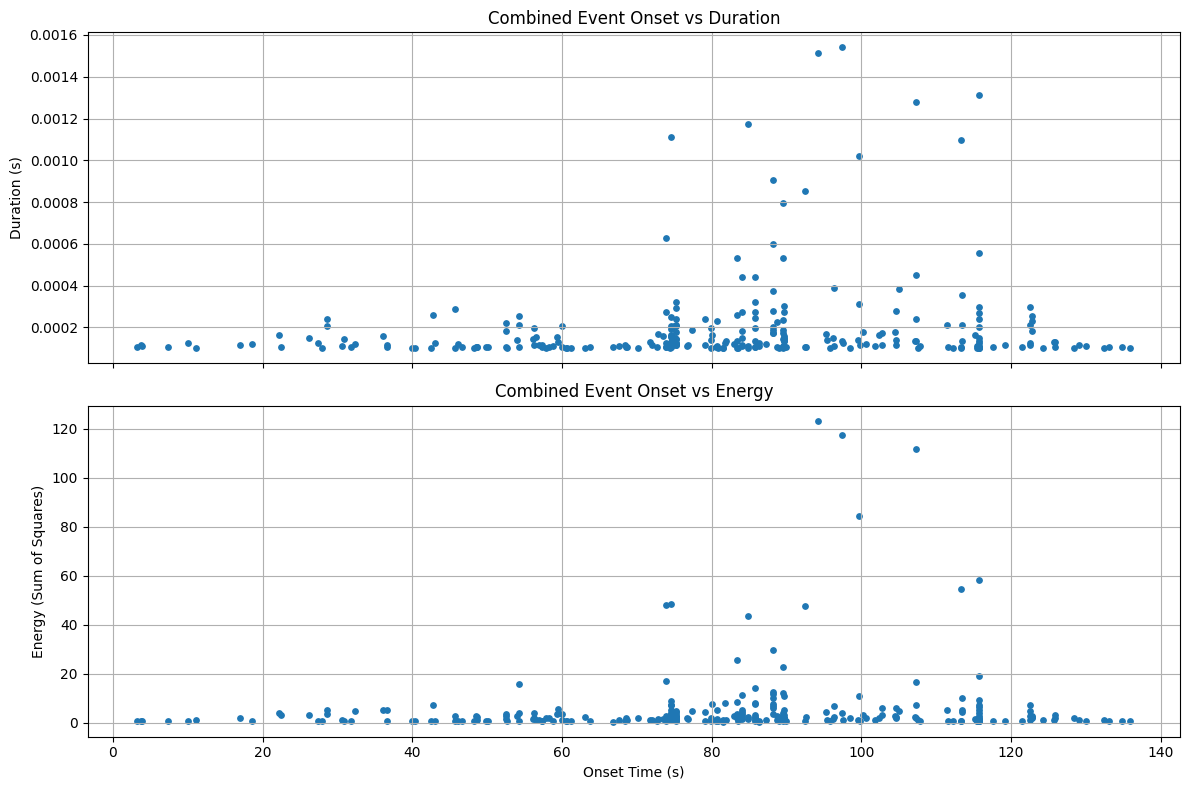

In [5]:
plot_event_timing_duration_energy(combined_events)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_event_cumulative_duration_energy(combined_events):
    """
    Creates:
      Subplot 1: onset time vs cumulative duration
      Subplot 2: onset time vs cumulative energy (cumulative sum of squares)
    """

    # Sort chronologically
    events = sorted(
        combined_events.values(),
        key=lambda r: r["global_start_sample"]
    )

    onset_times = []
    durations = []
    energies = []

    for rec in events:
        onset_times.append(rec["global_start_time_s"])
        durations.append(rec["duration_s"])
        energies.append(np.sum(np.square(rec["signal"])))

    onset_times = np.array(onset_times)
    durations = np.array(durations)
    energies = np.array(energies)

    cum_durations = np.cumsum(durations)
    cum_energies = np.cumsum(energies)

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Subplot 1: Cumulative duration
    axes[0].scatter(onset_times, cum_durations, s=15)
    axes[0].set_ylabel("Cumulative Duration (s)")
    axes[0].set_title("Combined Event Onset vs Cumulative Duration")
    axes[0].grid(True)

    # Subplot 2: Cumulative energy
    axes[1].scatter(onset_times, cum_energies, s=15)
    axes[1].set_xlabel("Onset Time (s)")
    axes[1].set_ylabel("Cumulative Energy (Sum of Squares)")
    axes[1].set_title("Combined Event Onset vs Cumulative Energy")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

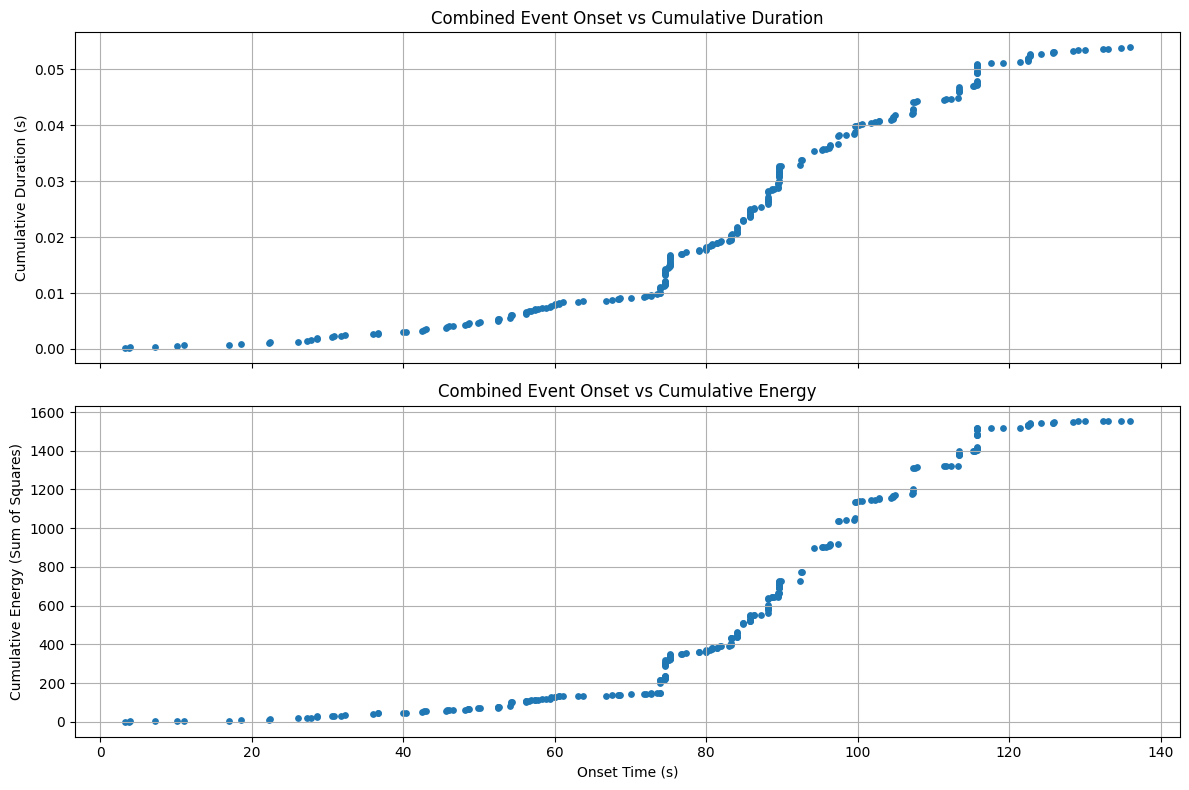

In [7]:
plot_event_cumulative_duration_energy(combined_events)

In [6]:
def plot_cumulative_dual_axis(combined_events):
    """
    Plot cumulative duration (left axis) and cumulative energy (right axis)
    versus event onset time with larger fonts.
    """

    # Sort chronologically
    events = sorted(
        combined_events.values(),
        key=lambda r: r["global_start_sample"]
    )

    onset_times = []
    durations = []
    energies = []

    for rec in events:
        onset_times.append(rec["global_start_time_s"])
        durations.append(rec["duration_s"])
        energies.append(np.sum(np.square(rec["signal"])))

    onset_times = np.array(onset_times)
    cum_durations = np.cumsum(durations)
    cum_energies = np.cumsum(energies)

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left axis (Duration)
    ax1.plot(onset_times, cum_durations, color='blue', linewidth=2.5)
    ax1.set_xlabel("Onset Time (s)", fontsize=16)
    ax1.set_ylabel("Cumulative Duration (s)", fontsize=16, color='blue')
    ax1.tick_params(axis='both', labelsize=14)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(True)

    # Right axis (Energy)
    ax2 = ax1.twinx()
    ax2.plot(onset_times, cum_energies, color='red', linewidth=2.5)
    ax2.set_ylabel("Cumulative Energy (Sum of Squares)", fontsize=16, color='red')
    ax2.tick_params(axis='y', labelsize=14, labelcolor='red')

    plt.title("Cumulative Duration and Energy vs Event Onset Time",
              fontsize=18)

    plt.tight_layout()
    plt.show()

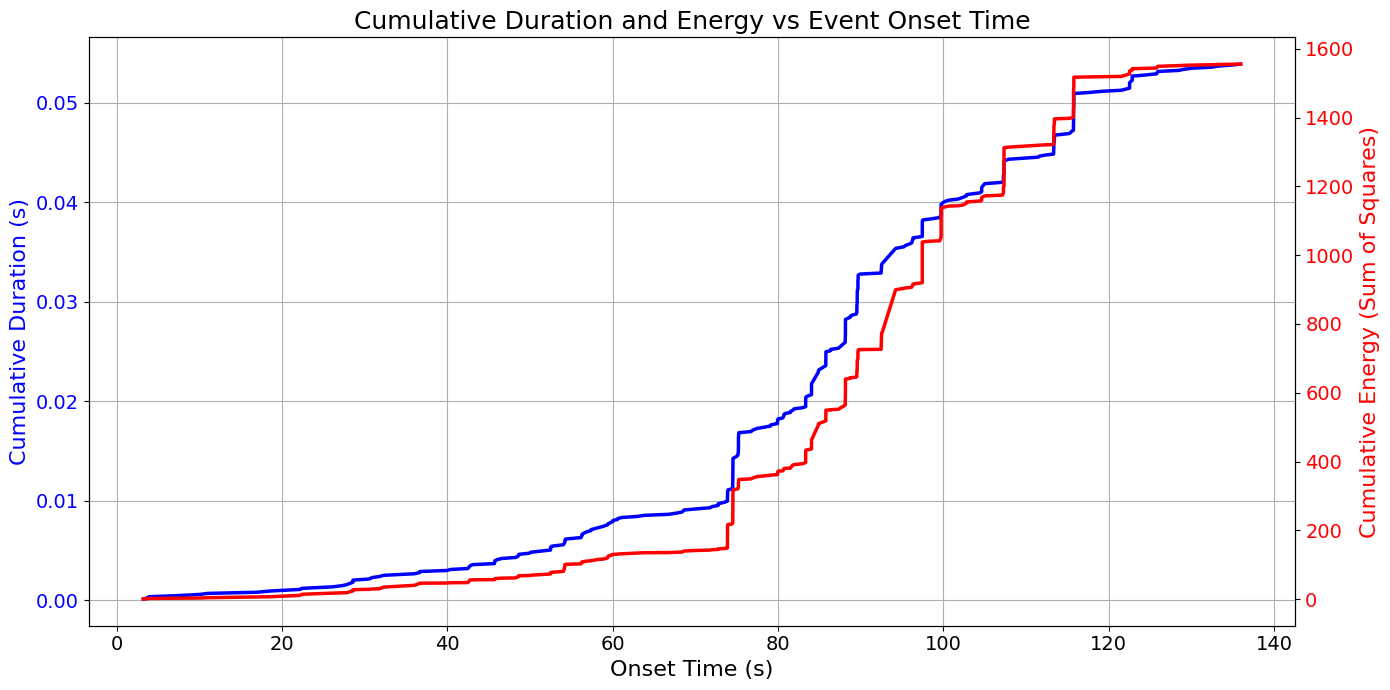

In [11]:
plot_cumulative_dual_axis(combined_events)

### Time Domain Classifiers: KNN

Key Issue: KNN requires fixed-length feature vectors.

Your snippets:
- Have variable durations
- Have different numbers of samples
- Have different total energy (which can dominate Euclidean distance)

So we must normalize properly.

What I Recommend (for a time-domain KNN baseline)

Option A (Simple + Strong Baseline)
1. Resample every snippet to a fixed length
- Interpolate each signal to e.g. 512 samples
- This preserves shape but standardizes dimension

2. Amplitude normalize
- Divide each snippet by its RMS (or max abs value)
- Removes pure energy scaling

3. Standardize features (important for KNN)
- Use StandardScaler() before KNN

This gives you:
X shape = (n_samples, 512)

Here Is the Full KNN Pipeline

This version:
- Resamples to 512 samples
- RMS normalizes
- Standard scales
- Tries K = 1 → 25
- Plots accuracy vs K

In [16]:
import numpy as np
from scipy.signal import resample

def build_Xy_resampled(combined_events, non_event_signals, fixed_length=512):
    X, y = [], []

    # label 1 = event
    for rec in combined_events.values():
        sig = np.asarray(rec["signal"], dtype=float)
        sig_rs = resample(sig, fixed_length)

        rms = np.sqrt(np.mean(sig_rs**2))
        if rms > 0:
            sig_rs = sig_rs / rms

        X.append(sig_rs)
        y.append(1)

    # label 0 = non-event
    for rec in non_event_signals.values():
        sig = np.asarray(rec["signal"], dtype=float)
        sig_rs = resample(sig, fixed_length)

        rms = np.sqrt(np.mean(sig_rs**2))
        if rms > 0:
            sig_rs = sig_rs / rms

        X.append(sig_rs)
        y.append(0)

    return np.asarray(X), np.asarray(y)

In [17]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

def run_knn_with_confusion(
    combined_events,
    non_event_signals,
    fixed_length=512,
    k_values=range(1, 26),
    test_size=0.3,
    random_state=42
):
    X, y = build_Xy_resampled(combined_events, non_event_signals, fixed_length=fixed_length)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    accs = []
    models = []

    for k in k_values:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k))
        ])
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accs.append(acc)
        models.append(model)

    best_idx = int(np.argmax(accs))
    best_k = list(k_values)[best_idx]
    best_model = models[best_idx]
    best_acc = accs[best_idx]

    print(f"Best KNN: K={best_k}, Accuracy={best_acc:.4f}")

    # Confusion matrix on held-out test
    y_best = best_model.predict(X_test)
    cm = confusion_matrix(y_test, y_best, labels=[0, 1])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non-event", "event"])
    disp.plot(values_format="d")
    plt.title(f"KNN Confusion Matrix (K={best_k})")
    plt.grid(False)
    plt.show()

    print("\nClassification report (test set):")
    print(classification_report(y_test, y_best, target_names=["non-event", "event"], digits=4))

    # Accuracy vs K plot
    plt.figure(figsize=(8, 4))
    plt.plot(list(k_values), accs, marker="o")
    plt.xlabel("K")
    plt.ylabel("Accuracy")
    plt.title("KNN Accuracy vs K")
    plt.grid(True)
    plt.show()

    return best_model, best_k, best_acc

Best KNN: K=4, Accuracy=0.9214


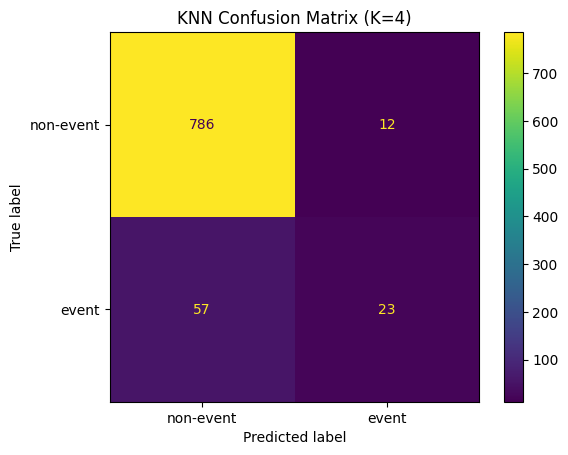


Classification report (test set):
              precision    recall  f1-score   support

   non-event     0.9324    0.9850    0.9580       798
       event     0.6571    0.2875    0.4000        80

    accuracy                         0.9214       878
   macro avg     0.7948    0.6362    0.6790       878
weighted avg     0.9073    0.9214    0.9071       878



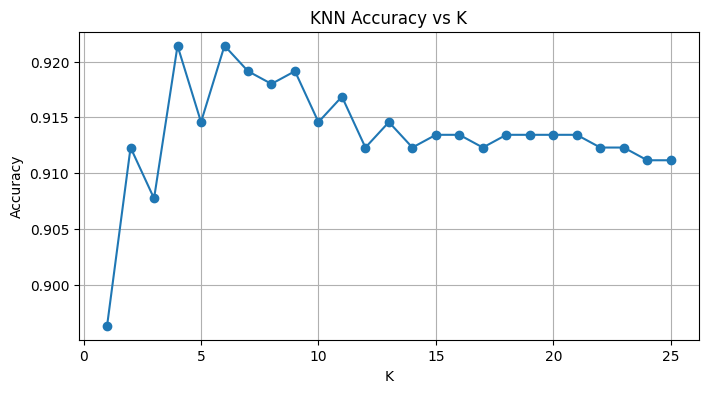

In [18]:
best_knn, best_k, best_knn_acc = run_knn_with_confusion(combined_events, non_event_signals)

### SVM Time Domain Classifier

For SVM, you’ll want the same fixed-length representation + scaling (SVM is very sensitive to feature scale).

Normalization recommendation (same logic as KNN)

Because snippets are variable length, make them comparable by:
1. Resample each snippet to a fixed length (e.g., 512 or 1024 samples)
2. Amplitude normalize (RMS normalization is a good default)
3. Standardize features (zero mean / unit variance using StandardScaler)
4.Train SVM with a few kernels / C values

Below is an SVM version that:
- Resamples to fixed length
- RMS-normalizes
- Standard-scales
- Tries a grid over C and gamma for RBF SVM, plus a linear SVM baseline
- Reports best accuracy and plots a simple summary

We'll use:
- Pipeline(StandardScaler -> PCA -> SVC)
- GridSearchCV with StratifiedKFold
- scoring: f1 (better than accuracy with imbalance), but you can change to "accuracy".

In [21]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt


def run_svm_pca_cv_with_progress(
    combined_events,
    non_event_signals,
    fixed_length=512,
    test_size=0.3,
    random_state=42,
    n_splits=5,
    scoring="f1"
):
    X, y = build_Xy_resampled(combined_events, non_event_signals, fixed_length=fixed_length)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Reduced grid (faster than previous full grid)
    pca_components = [25, 50]
    C_list = [0.1, 1, 10]
    gamma_list = ["scale", 1e-2]

    param_grid = []

    # Linear
    for n in pca_components:
        for C in C_list:
            param_grid.append(("linear", n, C, None))

    # RBF
    for n in pca_components:
        for C in C_list:
            for gamma in gamma_list:
                param_grid.append(("rbf", n, C, gamma))

    best_score = -np.inf
    best_model = None
    best_params = None

    print(f"Total models to evaluate: {len(param_grid)}")

    for kernel, n_comp, C, gamma in tqdm(param_grid):

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n_comp, random_state=random_state)),
            ("svm", SVC(kernel=kernel, C=C,
                        gamma=gamma if kernel == "rbf" else "scale",
                        class_weight="balanced"))
        ])

        cv_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            pipe.fit(X_train[train_idx], y_train[train_idx])
            y_val = pipe.predict(X_train[val_idx])

            if scoring == "f1":
                score = f1_score(y_train[val_idx], y_val)
            else:
                from sklearn.metrics import accuracy_score
                score = accuracy_score(y_train[val_idx], y_val)

            cv_scores.append(score)

        mean_score = np.mean(cv_scores)

        if mean_score > best_score:
            best_score = mean_score
            best_model = pipe
            best_params = (kernel, n_comp, C, gamma)

    print("\nBest CV Params:")
    print(f"Kernel={best_params[0]}, PCA={best_params[1]}, C={best_params[2]}, gamma={best_params[3]}")
    print(f"Best CV {scoring}: {best_score:.4f}")

    # Final evaluation on held-out test
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=[0,1])
    disp = ConfusionMatrixDisplay(cm, display_labels=["non-event","event"])
    disp.plot(values_format="d")
    plt.title("SVM+PCA Confusion Matrix (Held-Out Test)")
    plt.grid(False)
    plt.show()

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred, target_names=["non-event","event"], digits=4))

    return best_model, best_params, best_score

Total models to evaluate: 18


100%|██████████| 18/18 [05:47<00:00, 19.29s/it]



Best CV Params:
Kernel=rbf, PCA=50, C=1, gamma=scale
Best CV f1: 0.4522


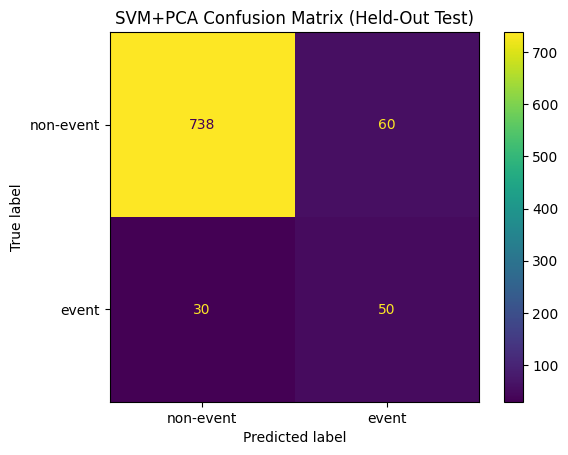


Classification Report (Test):
              precision    recall  f1-score   support

   non-event     0.9609    0.9248    0.9425       798
       event     0.4545    0.6250    0.5263        80

    accuracy                         0.8975       878
   macro avg     0.7077    0.7749    0.7344       878
weighted avg     0.9148    0.8975    0.9046       878



In [22]:
best_model, best_params, best_score = run_svm_pca_cv_with_progress(
    combined_events,
    non_event_signals,
    fixed_length=512,
    n_splits=5,
    scoring="f1"
)

## Enhanced Event Analysis

### Load the stress-strain curve

First, load the following csv file "P36_10um_Test1_synced.csv" as we'll use the data in here as well. Extract the time column in a variable called "strain_time", the Strain in a variable called "strain", and the Stress in a variable called "stress". Make those three variables numpy arrays.

In [8]:
!pwd

/content/drive/My Drive/EE269_Signal_Proc_ML/Project/Acoustic_Emissions/Data/AE


In [3]:
import pandas as pd
import numpy as np

# ---- Load CSV ----
csv_path = "P36_10um_Test1_synced_clean.csv"
df = pd.read_csv(csv_path)

print("Columns in CSV:")
print(df.columns)

print("Columns:", list(df.columns))

# If your headers are exactly these:
strain_time = df["Time (s)"].to_numpy(dtype=float)
strain = df["Strain (%)"].to_numpy(dtype=float)
stress = df["Stress (Mpa)"].to_numpy(dtype=float)

print("strain_time:", strain_time.shape, strain_time.dtype)
print("strain (%):", strain.shape, strain.dtype)
print("stress:", stress.shape, stress.dtype)

Columns in CSV:
Index(['Time (s)', 'Displacement (nm)', 'Depth (µm)', 'Strain (%)',
       'Force (mN)', 'Load (mN)', 'Stress (Mpa)', 'd(Disp)/d(Time) (nm/s)'],
      dtype='object')
Columns: ['Time (s)', 'Displacement (nm)', 'Depth (µm)', 'Strain (%)', 'Force (mN)', 'Load (mN)', 'Stress (Mpa)', 'd(Disp)/d(Time) (nm/s)']
strain_time: (80672,) float64
strain (%): (80672,) float64
stress: (80672,) float64


Now let's plot a new cumulative energy plot like we did in "plot_cumulative_dual_axis(combined_events)". But this time overlay the cumulative energy vs Event Onset time with the strain curve, where the strain curve uses the "strain_time" variable as its x axis.

Here’s a drop-in replacement for plot_cumulative_energy_with_strain that:
- Plots cumulative duration (blue) on a right y-axis
- Plots cumulative energy (red) on the left y-axis
- Plots strain (black) on the same left y-axis, but normalized to the energy scale
- Adds a combined legend
- Uses bigger fonts

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_energy_duration_with_strain(
    combined_events,
    strain_time,
    strain,
    font_size=13,
):
    # ---- Sort events by onset time ----
    events_sorted = sorted(combined_events.values(), key=lambda e: e["global_start_time_s"])
    onset_times = np.array([e["global_start_time_s"] for e in events_sorted], dtype=float)

    # ---- Per-event energy + duration ----
    energies = np.array([np.sum(np.asarray(e["signal"], dtype=float) ** 2) for e in events_sorted], dtype=float)
    durations = np.array([float(e.get("duration_s", 0.0)) for e in events_sorted], dtype=float)

    cumulative_energy = np.cumsum(energies)
    cumulative_duration = np.cumsum(durations)

    # ---- Normalize strain onto the energy scale (min-max to energy range) ----
    strain_time = np.asarray(strain_time, dtype=float)
    strain = np.asarray(strain, dtype=float)

    e_min, e_max = float(np.nanmin(cumulative_energy)), float(np.nanmax(cumulative_energy))
    s_min, s_max = float(np.nanmin(strain)), float(np.nanmax(strain))

    if np.isfinite(s_min) and np.isfinite(s_max) and (s_max - s_min) > 0:
        strain_norm = (strain - s_min) / (s_max - s_min)
        strain_on_energy_scale = e_min + strain_norm * (e_max - e_min)
    else:
        # Fallback: flat line if strain is constant/invalid
        strain_on_energy_scale = np.full_like(strain, fill_value=(e_min + e_max) / 2.0)

    # ---- Plot ----
    fig, ax_energy = plt.subplots(figsize=(11, 5))

    # Left axis: energy (red) + normalized strain (black)
    l_energy, = ax_energy.plot(onset_times, cumulative_energy, color="red", label="Cumulative AE Energy")
    l_strain, = ax_energy.plot(strain_time, strain_on_energy_scale, color="black", label="Strain (normalized to energy scale)")

    ax_energy.set_xlabel("Time (s)", fontsize=font_size)
    ax_energy.set_ylabel("Cumulative AE Energy (sum(signal^2))", fontsize=font_size)
    ax_energy.tick_params(axis="both", labelsize=font_size - 1)
    ax_energy.grid(True)

    # Right axis: cumulative duration (blue)
    ax_dur = ax_energy.twinx()
    l_dur, = ax_dur.plot(onset_times, cumulative_duration, color="blue", label="Cumulative AE Duration")
    ax_dur.set_ylabel("Cumulative AE Duration (s)", fontsize=font_size)
    ax_dur.tick_params(axis="y", labelsize=font_size - 1)

    # Title
    ax_energy.set_title("Cumulative AE Energy + Duration with Strain Overlay", fontsize=font_size + 1)

    # ---- Single legend combining both axes ----
    lines = [l_energy, l_dur, l_strain]
    labels = [ln.get_label() for ln in lines]
    ax_energy.legend(lines, labels, fontsize=font_size - 1, loc="best")

    plt.tight_layout()
    plt.show()

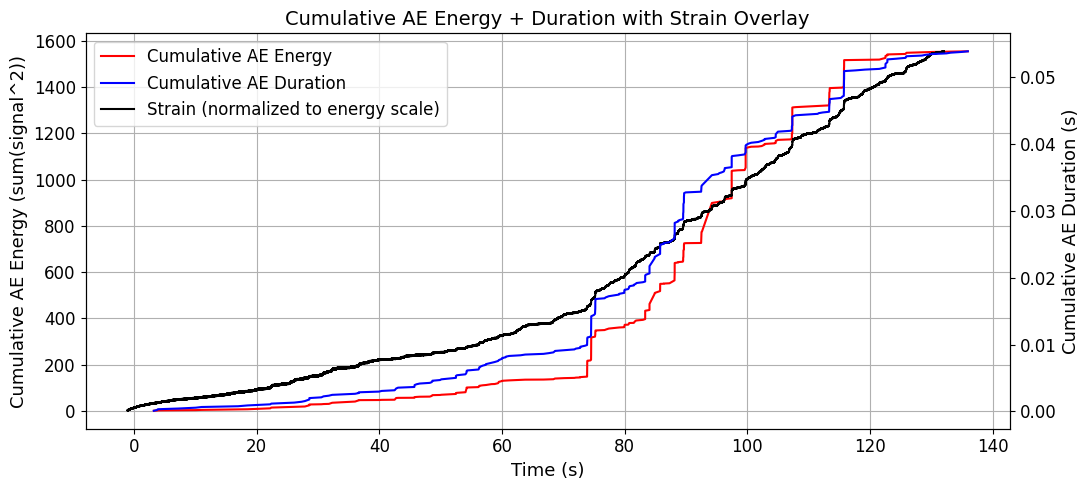

In [19]:
# Run it
plot_cumulative_energy_duration_with_strain(combined_events, strain_time, strain)

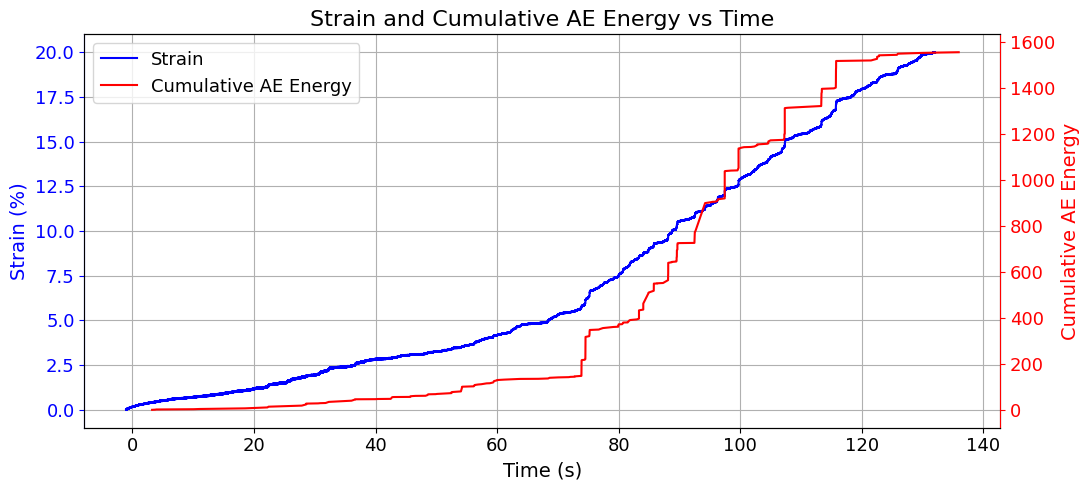

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_energy_with_strain(combined_events, strain_time, strain):

    # ---- Sort events by onset time ----
    events_sorted = sorted(combined_events.values(), key=lambda e: e["global_start_time_s"])
    onset_times = np.array([e["global_start_time_s"] for e in events_sorted], dtype=float)

    # ---- Compute cumulative AE energy ----
    energies = np.array([
        np.sum(np.asarray(e["signal"], dtype=float)**2)
        for e in events_sorted
    ], dtype=float)

    cumulative_energy = np.cumsum(energies)

    strain_time_arr = np.asarray(strain_time, dtype=float)
    strain_arr = np.asarray(strain, dtype=float)

    FONT_TITLE = 16
    FONT_LABEL = 14
    FONT_TICKS = 13

    fig, ax_strain = plt.subplots(figsize=(11,5))

    # ---- Strain (blue) on LEFT axis ----
    line_strain, = ax_strain.plot(
        strain_time_arr,
        strain_arr,
        color="blue",
        label="Strain"
    )

    ax_strain.set_xlabel("Time (s)", fontsize=FONT_LABEL)
    ax_strain.set_ylabel("Strain (%)", fontsize=FONT_LABEL, color="blue")
    ax_strain.tick_params(axis='y', labelsize=FONT_TICKS, colors="blue")
    ax_strain.tick_params(axis='x', labelsize=FONT_TICKS)
    ax_strain.spines["left"].set_color("blue")
    ax_strain.grid(True)

    # ---- AE cumulative energy (red) on RIGHT axis ----
    ax_energy = ax_strain.twinx()

    line_energy, = ax_energy.plot(
        onset_times,
        cumulative_energy,
        color="red",
        label="Cumulative AE Energy"
    )

    ax_energy.set_ylabel("Cumulative AE Energy", fontsize=FONT_LABEL, color="red")
    ax_energy.tick_params(axis='y', labelsize=FONT_TICKS, colors="red")
    ax_energy.spines["right"].set_color("red")

    # ---- Combined legend ----
    lines = [line_strain, line_energy]
    labels = [l.get_label() for l in lines]
    ax_strain.legend(lines, labels, fontsize=FONT_TICKS)

    ax_strain.set_title(
        "Strain and Cumulative AE Energy vs Time",
        fontsize=FONT_TITLE
    )

    plt.tight_layout()
    plt.show()


# Run
plot_cumulative_energy_with_strain(combined_events, strain_time, strain)

### AE vs stress derivative

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stress_derivative_hann(strain_time, stress, window_length=51):
    """
    window_length: must be odd and >= 3
    """

    t = np.asarray(strain_time, dtype=float)
    s = np.asarray(stress, dtype=float)

    # Sort by time (safety)
    order = np.argsort(t)
    t = t[order]
    s = s[order]

    # Remove non-finite values
    mask = np.isfinite(t) & np.isfinite(s)
    t = t[mask]
    s = s[mask]

    # ---- Hann smoothing ----
    if window_length is not None and window_length > 2:
        if window_length % 2 == 0:
            window_length += 1  # enforce odd length

        window = np.hanning(window_length)
        window /= window.sum()

        # pad to reduce edge shrinkage
        pad = window_length // 2
        s_padded = np.pad(s, pad_width=pad, mode="edge")
        s_smooth = np.convolve(s_padded, window, mode="valid")
    else:
        s_smooth = s

    # ---- Derivative ----
    dstress_dt = np.gradient(s_smooth, t)

    # ---- Plot ----
    plt.figure(figsize=(11, 4.5))
    plt.plot(t, dstress_dt)
    plt.grid(True)
    plt.xlabel("Time (s)", fontsize=13)
    plt.ylabel("d(Stress)/dt", fontsize=13)
    plt.title("Stress Derivative vs Time (Hann-smoothed)", fontsize=14)
    plt.tight_layout()
    plt.show()

    return dstress_dt

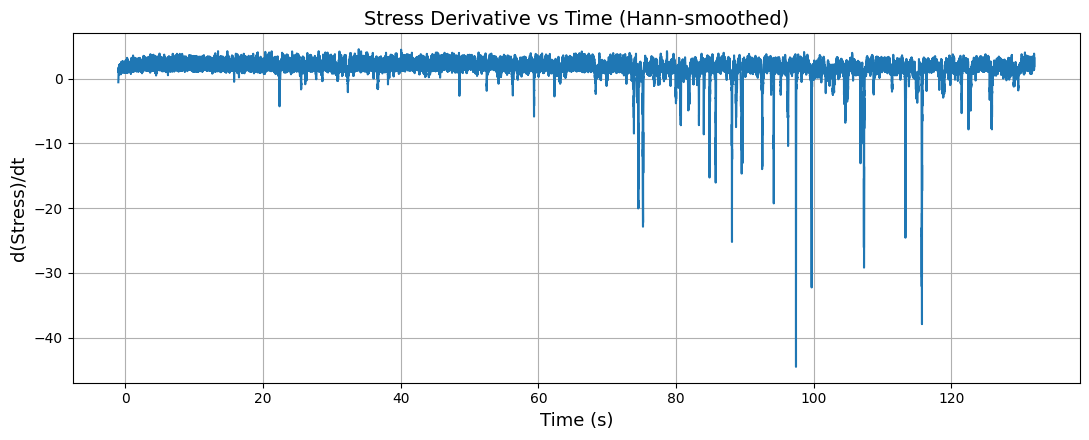

In [5]:
# Run it (set smooth_window=0 for no smoothing; try e.g. 21 if it's noisy)
dstress_dt = plot_stress_derivative_hann(strain_time, stress, window_length=51)

I want to correlate the stress derivative with the combined events onset energies. Create a signal on the same time scale as that of the stress (namely strain_time). Have this signal be zeros everywhere to start. Then add spikes equal to the energy of each combined event. The spike should be 1 sample in duration and located at the end of the event (event onset + event duration). Call this signal "AE_energy_time". Then plot a 3x1 subplot where the first plot is the smoother stress derivative you just calculated, the second is the AE_energy_time signal. The third is the cross correlaion of the two for lags of +/- 100

Here’s a clean drop-in version that implements all requested changes:
- Normalize smoothed stress derivative to max magnitude = 1
- Normalize AE energy spikes to max magnitude = 1
- Cross-correlation lags ±50 samples
- Cross-correlation normalized by signal std devs (i.e., correlation-like scaling)

Report the lag with maximum |correlation| and the corresponding time delta (using median dt from strain_time)

Max |corr| at lag = -2 samples, corr = -0.1834
Approx time delta = -0.003888 s (dt≈0.001944 s/sample)


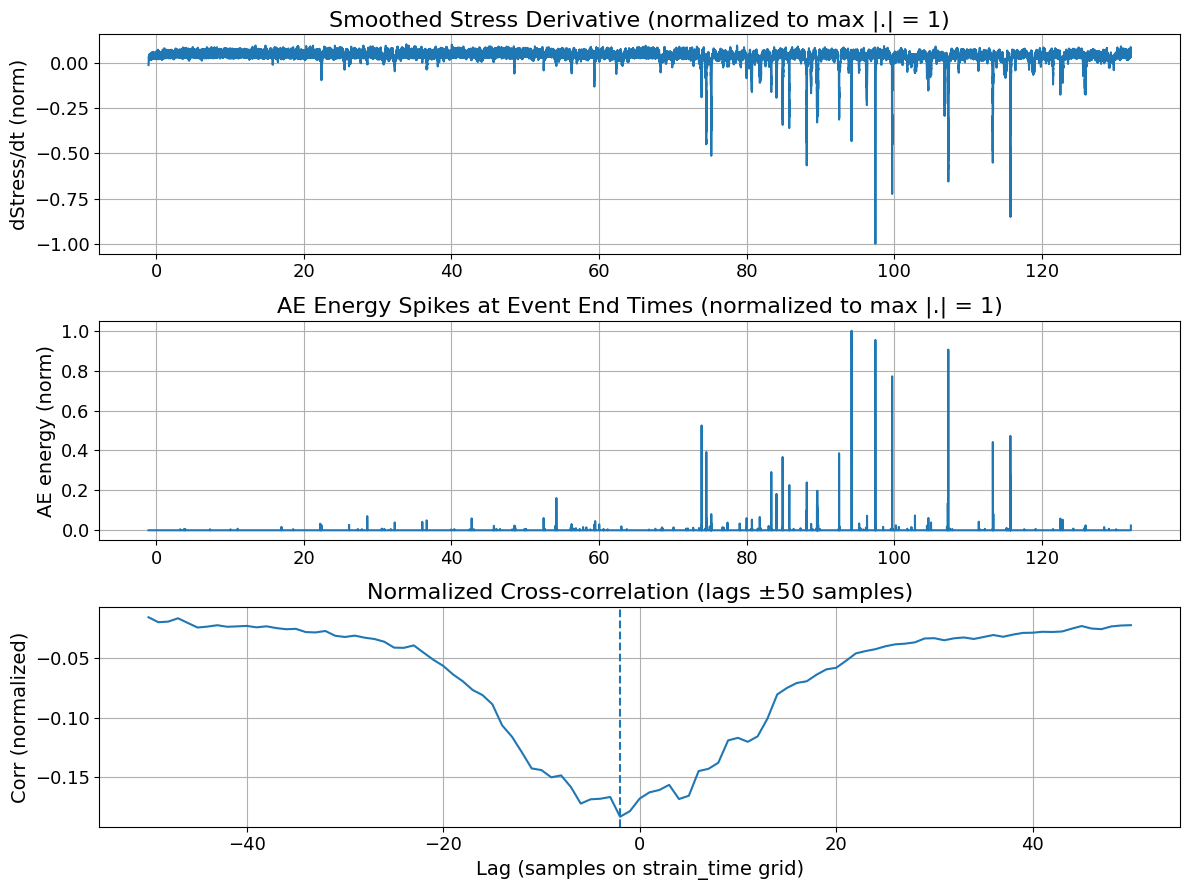

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def hann_smooth(x, window_length=51):
    x = np.asarray(x, dtype=float)
    if window_length is None or window_length <= 2:
        return x
    if window_length % 2 == 0:
        window_length += 1
    w = np.hanning(window_length)
    w /= w.sum()
    pad = window_length // 2
    x_pad = np.pad(x, pad_width=pad, mode="edge")
    return np.convolve(x_pad, w, mode="valid")

def normalize_to_mag1(x, eps=1e-12):
    x = np.asarray(x, dtype=float)
    m = np.max(np.abs(x))
    return x / (m + eps)

# ---------- 1) Smoothed stress derivative, normalized to |max|=1 ----------
t = np.asarray(strain_time, dtype=float)
s = np.asarray(stress, dtype=float)

order = np.argsort(t)
t = t[order]
s = s[order]
mask = np.isfinite(t) & np.isfinite(s)
t = t[mask]
s = s[mask]

stress_smooth = hann_smooth(s, window_length=51)
dstress_dt = np.gradient(stress_smooth, t)
dstress_dt_n = normalize_to_mag1(dstress_dt)

# ---------- 2) AE energy spikes at event end times, normalized to |max|=1 ----------
AE_energy_time = np.zeros_like(t, dtype=float)

events_sorted = sorted(combined_events.values(), key=lambda e: e["global_start_time_s"])
for e in events_sorted:
    onset = float(e["global_start_time_s"])
    dur = float(e.get("duration_s", 0.0))
    end_time = onset + dur

    energy = float(np.sum(np.asarray(e["signal"], dtype=float) ** 2))

    idx = int(np.argmin(np.abs(t - end_time)))
    AE_energy_time[idx] += energy  # accumulate if multiple map to same sample

AE_energy_time_n = normalize_to_mag1(AE_energy_time)

# ---------- 3) Normalized cross-correlation for lags +/- 50 ----------
max_lag = 50

# subtract means for correlation-like behavior
x = dstress_dt_n - np.mean(dstress_dt_n)
y = AE_energy_time_n - np.mean(AE_energy_time_n)

sx = np.std(x)
sy = np.std(y)

# If a signal is flat, correlation isn't meaningful
if sx < 1e-12 or sy < 1e-12:
    raise ValueError("One of the signals has ~zero variance after normalization; cannot compute normalized correlation reliably.")

corr_full = np.correlate(x, y, mode="full")
mid = len(corr_full) // 2
lags = np.arange(-max_lag, max_lag + 1)

xcorr = corr_full[mid - max_lag : mid + max_lag + 1]

# Normalize by std devs and length to make it scale like correlation coefficient
# (divide by N as well for comparability across signals)
N = len(x)
xcorr_norm = xcorr / (N * sx * sy)

# ---------- 4) Find max |correlation| lag and convert to time delta ----------
k = int(np.argmax(np.abs(xcorr_norm)))
best_lag = int(lags[k])
best_corr = float(xcorr_norm[k])

# time delta: use median dt (works for slightly non-uniform sampling)
dt = np.median(np.diff(t))
time_delta = best_lag * dt

print(f"Max |corr| at lag = {best_lag} samples, corr = {best_corr:.4f}")
print(f"Approx time delta = {time_delta:.6f} s (dt≈{dt:.6f} s/sample)")

# ---------- Plot 3x1 with larger fonts ----------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

# Stress derivative
axes[0].plot(t, dstress_dt_n)
axes[0].set_title("Smoothed Stress Derivative (normalized to max |.| = 1)", fontsize=FONT_TITLE)
axes[0].set_ylabel("dStress/dt (norm)", fontsize=FONT_LABEL)
axes[0].tick_params(axis='both', labelsize=FONT_TICKS)
axes[0].grid(True)

# AE energy spikes
axes[1].plot(t, AE_energy_time_n)
axes[1].set_title("AE Energy Spikes at Event End Times (normalized to max |.| = 1)", fontsize=FONT_TITLE)
axes[1].set_ylabel("AE energy (norm)", fontsize=FONT_LABEL)
axes[1].tick_params(axis='both', labelsize=FONT_TICKS)
axes[1].grid(True)

# Cross correlation
axes[2].plot(lags, xcorr_norm)
axes[2].axvline(best_lag, linestyle="--")
axes[2].set_title("Normalized Cross-correlation (lags ±50 samples)", fontsize=FONT_TITLE)
axes[2].set_xlabel("Lag (samples on strain_time grid)", fontsize=FONT_LABEL)
axes[2].set_ylabel("Corr (normalized)", fontsize=FONT_LABEL)
axes[2].tick_params(axis='both', labelsize=FONT_TICKS)
axes[2].grid(True)

plt.tight_layout()
plt.show()

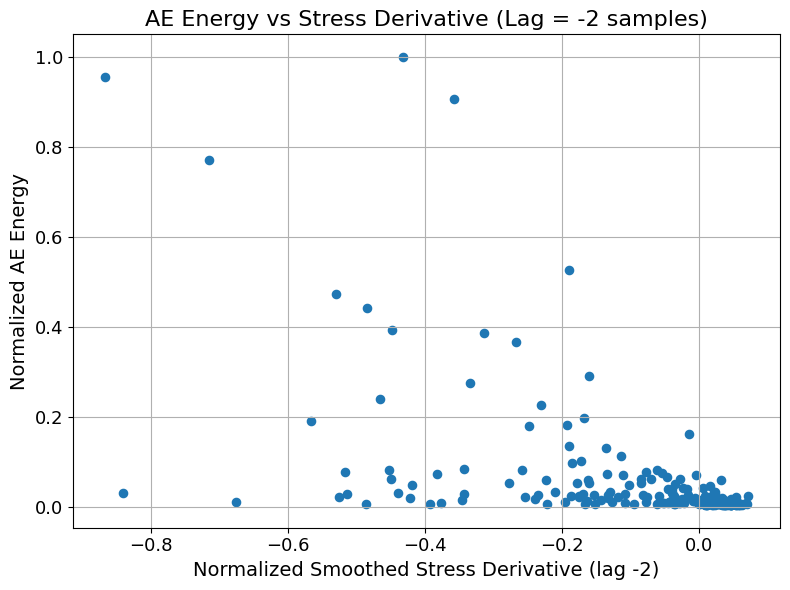

Number of AE events plotted: 209
Lag used: -2 samples


In [8]:
# ---------- Scatter with -2 lag ----------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

lag = -2

# event indices
event_idx = np.where(AE_energy_time_n > 0)[0]

# apply lag safely
valid = event_idx + lag >= 0
event_idx = event_idx[valid]

x_vals = dstress_dt_n[event_idx + lag]
y_vals = AE_energy_time_n[event_idx]

plt.figure(figsize=(8,6))

plt.scatter(x_vals, y_vals, s=35)

plt.xlabel("Normalized Smoothed Stress Derivative (lag -2)", fontsize=FONT_LABEL)
plt.ylabel("Normalized AE Energy", fontsize=FONT_LABEL)
plt.title("AE Energy vs Stress Derivative (Lag = -2 samples)", fontsize=FONT_TITLE)

plt.xticks(fontsize=FONT_TICKS)
plt.yticks(fontsize=FONT_TICKS)

plt.grid(True)
plt.tight_layout()
plt.show()

print("Number of AE events plotted:", len(x_vals))
print("Lag used:", lag, "samples")

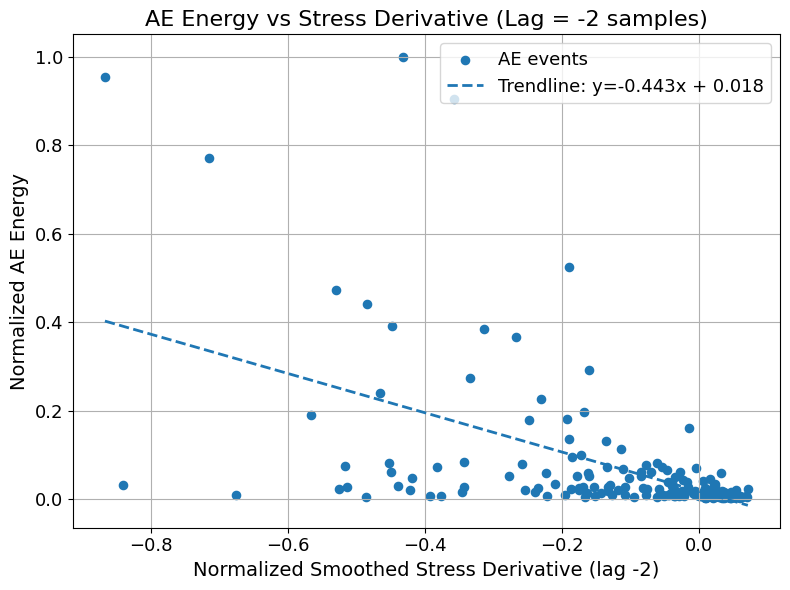

Number of AE events plotted: 209
Lag used: -2 samples
Linear fit: slope = -0.4434, intercept = 0.0183


In [9]:
# ---------- Scatter with -2 lag + linear trendline ----------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

lag = -2

# event indices
event_idx = np.where(AE_energy_time_n > 0)[0]

# apply lag safely
valid = event_idx + lag >= 0
event_idx = event_idx[valid]

x_vals = dstress_dt_n[event_idx + lag]
y_vals = AE_energy_time_n[event_idx]

plt.figure(figsize=(8,6))

# scatter
plt.scatter(x_vals, y_vals, s=35, label="AE events")

# ----- Linear trendline -----
if len(x_vals) > 1:
    m, b = np.polyfit(x_vals, y_vals, 1)

    x_line = np.linspace(np.min(x_vals), np.max(x_vals), 200)
    y_line = m * x_line + b

    plt.plot(
        x_line,
        y_line,
        linewidth=2,
        linestyle="--",   # dashed line
        label=f"Trendline: y={m:.3f}x + {b:.3f}"
    )

plt.xlabel("Normalized Smoothed Stress Derivative (lag -2)", fontsize=FONT_LABEL)
plt.ylabel("Normalized AE Energy", fontsize=FONT_LABEL)
plt.title("AE Energy vs Stress Derivative (Lag = -2 samples)", fontsize=FONT_TITLE)

plt.xticks(fontsize=FONT_TICKS)
plt.yticks(fontsize=FONT_TICKS)

plt.legend(fontsize=FONT_TICKS)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Number of AE events plotted:", len(x_vals))
print("Lag used:", lag, "samples")

if len(x_vals) > 1:
    print(f"Linear fit: slope = {m:.4f}, intercept = {b:.4f}")

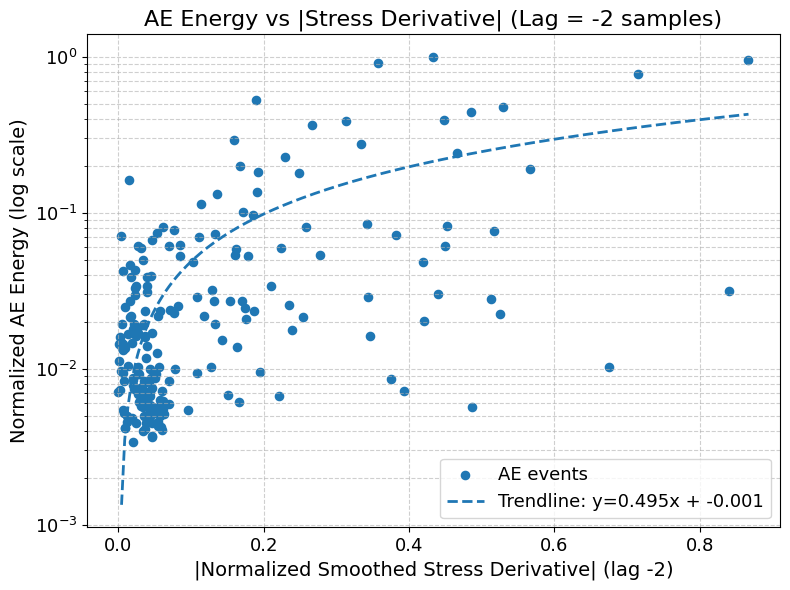

Number of AE events plotted: 209
Lag used: -2 samples
Linear fit: slope = 0.4945, intercept = -0.0009


In [10]:
# ---------- Scatter with -2 lag + dashed linear trendline + log y-axis ----------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

lag = -2

# event indices
event_idx = np.where(AE_energy_time_n > 0)[0]

# apply lag safely
valid = event_idx + lag >= 0
event_idx = event_idx[valid]

# absolute value for x-axis
x_vals = np.abs(dstress_dt_n[event_idx + lag])
y_vals = AE_energy_time_n[event_idx]

# ensure positive values for log scale
mask = y_vals > 0
x_vals = x_vals[mask]
y_vals = y_vals[mask]

plt.figure(figsize=(8,6))

# scatter
plt.scatter(x_vals, y_vals, s=35, label="AE events")

# ----- Linear trendline -----
if len(x_vals) > 1:
    m, b = np.polyfit(x_vals, y_vals, 1)

    x_line = np.linspace(np.min(x_vals), np.max(x_vals), 200)
    y_line = m * x_line + b

    valid_line = y_line > 0
    plt.plot(
        x_line[valid_line],
        y_line[valid_line],
        linewidth=2,
        linestyle="--",
        label=f"Trendline: y={m:.3f}x + {b:.3f}"
    )

plt.yscale("log")

plt.xlabel("|Normalized Smoothed Stress Derivative| (lag -2)", fontsize=FONT_LABEL)
plt.ylabel("Normalized AE Energy (log scale)", fontsize=FONT_LABEL)
plt.title("AE Energy vs |Stress Derivative| (Lag = -2 samples)", fontsize=FONT_TITLE)

plt.xticks(fontsize=FONT_TICKS)
plt.yticks(fontsize=FONT_TICKS)

plt.legend(fontsize=FONT_TICKS)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("Number of AE events plotted:", len(x_vals))
print("Lag used:", lag, "samples")

if len(x_vals) > 1:
    print(f"Linear fit: slope = {m:.4f}, intercept = {b:.4f}")

### Log-Log scatter plot



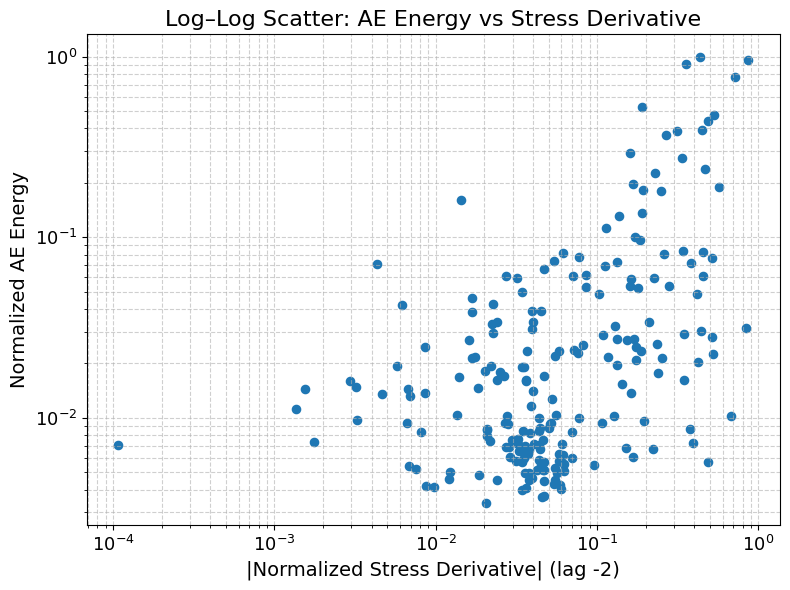

Points used in log-log plot: 209


In [11]:
# ---------- Log-log scatter version ----------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

# absolute stress derivative for log scale
x_log = np.abs(x_vals)
y_log = y_vals

# remove zeros (log cannot handle them)
mask = (x_log > 0) & (y_log > 0)
x_log = x_log[mask]
y_log = y_log[mask]

plt.figure(figsize=(8,6))

plt.scatter(x_log, y_log, s=35)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("|Normalized Stress Derivative| (lag -2)", fontsize=FONT_LABEL)
plt.ylabel("Normalized AE Energy", fontsize=FONT_LABEL)
plt.title("Log–Log Scatter: AE Energy vs Stress Derivative", fontsize=FONT_TITLE)

plt.xticks(fontsize=FONT_TICKS)
plt.yticks(fontsize=FONT_TICKS)

plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("Points used in log-log plot:", len(x_log))

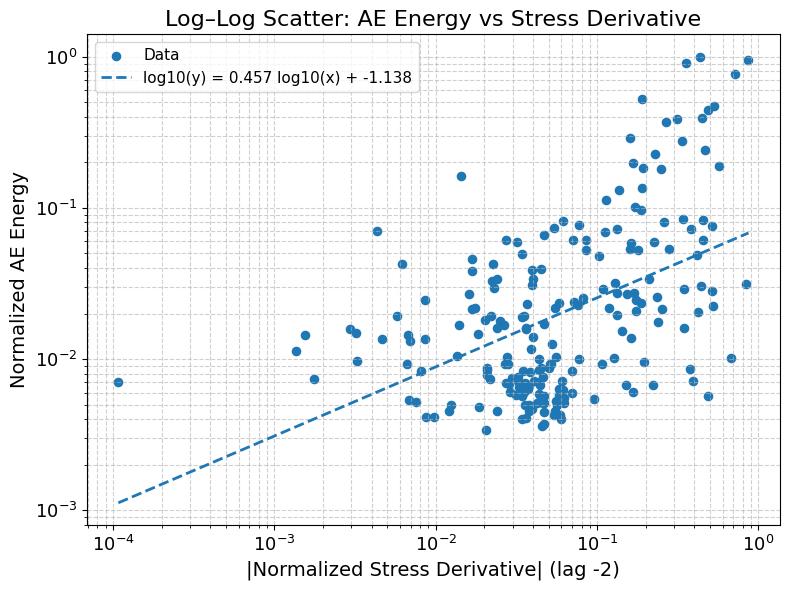

Points used in log-log plot: 209
Best-fit line in log10-log10 space: log10(y) = 0.4570 log10(x) + -1.1376
Equivalent power law: y = 0.07285 * x^0.4570


In [14]:
# ---------- Log-log scatter version with linear trendline in log-log space ----------
import numpy as np
import matplotlib.pyplot as plt

FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

# absolute stress derivative for log scale
x_log = np.abs(x_vals)
y_log = y_vals

# remove zeros / negatives (log cannot handle them)
mask = (x_log > 0) & (y_log > 0)
x_log = x_log[mask]
y_log = y_log[mask]

# fit line in log10-log10 space
lx = np.log10(x_log)
ly = np.log10(y_log)

m, b = np.polyfit(lx, ly, 1)

# trendline back in linear space for plotting on log-log axes
x_fit = np.logspace(np.log10(np.min(x_log)), np.log10(np.max(x_log)), 200)
y_fit = 10**b * x_fit**m

plt.figure(figsize=(8, 6))

plt.scatter(x_log, y_log, s=35, label="Data")
plt.plot(
    x_fit, y_fit,
    linewidth=2,
    linestyle="--",
    label=f"log10(y) = {m:.3f} log10(x) + {b:.3f}"
)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("|Normalized Stress Derivative| (lag -2)", fontsize=FONT_LABEL)
plt.ylabel("Normalized AE Energy", fontsize=FONT_LABEL)
plt.title("Log–Log Scatter: AE Energy vs Stress Derivative", fontsize=FONT_TITLE)

plt.xticks(fontsize=FONT_TICKS)
plt.yticks(fontsize=FONT_TICKS)
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
eqn_text = f"log10(y) = {m:.3f} log10(x) + {b:.3f}\ny = {10**b:.3g} x^{m:.3f}"
'''
plt.text(
    0.05, 0.95, eqn_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)
'''
plt.tight_layout()
plt.show()

print("Points used in log-log plot:", len(x_log))
print(f"Best-fit line in log10-log10 space: log10(y) = {m:.4f} log10(x) + {b:.4f}")
print(f"Equivalent power law: y = {10**b:.4g} * x^{m:.4f}")

### Histograms of energy bands

Now let's go back to the events by frequency band. I want to plot a histogram of onset time for each of the 8KHz, 25KHz, and 44 KHz events. can you compute these and plot on a 3x1 subplot where plot 1 is the 8KHz, plot2 the 25 KHz events, and plot 3 is the 44KHz events. Make the time scale equal to the duration of the signal

to do this we need the per-band event dictionary (the one that still has "band" per event), i.e. event_signals_8K_25K_44K. In your earlier pipeline that’s saved as event_signals_8K_25K_44K.pkl.

Below is a self-contained cell that:
- Loads event_signals_8K_25K_44K.pkl (if it isn’t already in memory)
- Extracts onset times for 8k / 25k / 44k
- Plots a 3×1 histogram (one per band)

Sets the x-axis time range to the full duration of your mechanical signal (uses strain_time if available; otherwise falls back to event times)

Counts: {'8k': 23, '25k': 174, '44k': 203}


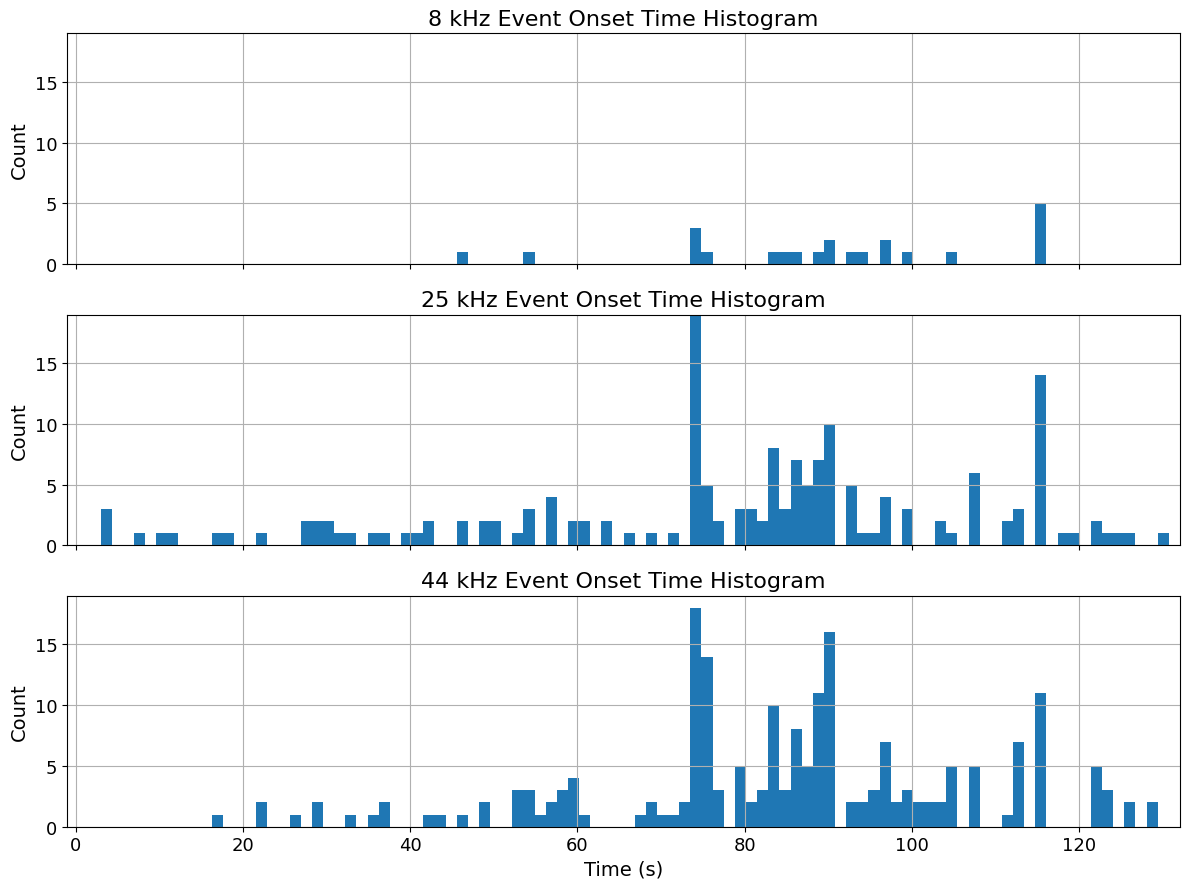

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# --------- Load per-band events (if needed) ----------
try:
    event_signals_8K_25K_44K
except NameError:
    # Update this path if your pkl is elsewhere / differently named
    pkl_path = "event_signals_8K_25K_44K.pkl"
    with open(pkl_path, "rb") as f:
        event_signals_8K_25K_44K = pickle.load(f)
    print("Loaded:", pkl_path, " (#events:", len(event_signals_8K_25K_44K), ")")

# --------- Extract onset times by band ----------
def get_onset_times_by_band(event_dict, band_value):
    times = []
    for ev in event_dict.values():
        # band label can vary; handle common variants
        b = str(ev.get("band", "")).lower()
        if b == str(band_value).lower():
            times.append(float(ev["global_start_time_s"]))
    return np.asarray(times, dtype=float)

t_8k  = get_onset_times_by_band(event_signals_8K_25K_44K, "8k")
t_25k = get_onset_times_by_band(event_signals_8K_25K_44K, "25k")
t_44k = get_onset_times_by_band(event_signals_8K_25K_44K, "44k")

print("Counts:", {"8k": len(t_8k), "25k": len(t_25k), "44k": len(t_44k)})

# --------- Define time axis limits = duration of the signal ----------
# Prefer strain_time (mechanical record duration)
if "strain_time" in globals():
    t_min = float(np.nanmin(strain_time))
    t_max = float(np.nanmax(strain_time))
else:
    # fallback: from AE event times (onset + duration if present)
    all_onsets = np.array(
        [float(ev["global_start_time_s"]) for ev in event_signals_8K_25K_44K.values()],
        dtype=float
    )
    all_ends = []
    for ev in event_signals_8K_25K_44K.values():
        onset = float(ev["global_start_time_s"])
        dur_us = ev.get("duration_us", None)
        if dur_us is not None:
            all_ends.append(onset + float(dur_us) * 1e-6)
        else:
            all_ends.append(onset)
    t_min = float(np.nanmin(all_onsets))
    t_max = float(np.nanmax(all_ends))

# Choose bins (you can tweak)
bins = 100

# Compute histogram counts first
counts_8k, bin_edges = np.histogram(t_8k, bins=bins, range=(t_min, t_max))
counts_25k, _ = np.histogram(t_25k, bins=bins, range=(t_min, t_max))
counts_44k, _ = np.histogram(t_44k, bins=bins, range=(t_min, t_max))

# Find common y-limit
ymax = max(counts_8k.max(), counts_25k.max(), counts_44k.max())

FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

fig, axes = plt.subplots(3,1, figsize=(12,9), sharex=True)

# 8 kHz
axes[0].hist(t_8k, bins=bins, range=(t_min, t_max))
axes[0].set_ylim(0, ymax)
axes[0].set_title("8 kHz Event Onset Time Histogram", fontsize=FONT_TITLE)
axes[0].set_ylabel("Count", fontsize=FONT_LABEL)
axes[0].tick_params(axis="both", labelsize=FONT_TICKS)
axes[0].grid(True)

# 25 kHz
axes[1].hist(t_25k, bins=bins, range=(t_min, t_max))
axes[1].set_ylim(0, ymax)
axes[1].set_title("25 kHz Event Onset Time Histogram", fontsize=FONT_TITLE)
axes[1].set_ylabel("Count", fontsize=FONT_LABEL)
axes[1].tick_params(axis="both", labelsize=FONT_TICKS)
axes[1].grid(True)

# 44 kHz
axes[2].hist(t_44k, bins=bins, range=(t_min, t_max))
axes[2].set_ylim(0, ymax)
axes[2].set_title("44 kHz Event Onset Time Histogram", fontsize=FONT_TITLE)
axes[2].set_xlabel("Time (s)", fontsize=FONT_LABEL)
axes[2].set_ylabel("Count", fontsize=FONT_LABEL)
axes[2].tick_params(axis="both", labelsize=FONT_TICKS)
axes[2].grid(True)

axes[2].set_xlim(t_min, t_max)

plt.tight_layout()
plt.show()

## Feature Exploration

Below is a compact but powerful ~20-feature acoustic-emission / microseismic feature set that is widely used in earthquake detection, microseismic monitoring, and AE fracture experiments. I’ll also include physical reasoning and literature connections, then suggest how we should implement it in your notebook.

This set is intentionally designed to capture four different aspects of the signal:
- Amplitude / energy
- Waveform shape
- Spectral structure
- Time-frequency behavior

Combining these typically improves classification substantially.

Recommended AE / Seismic Feature Set (~20 features)
1. Amplitude / Energy features (4): These relate to rupture energy release.

(i) Peak amplitude 𝐴_𝑚𝑎𝑥 =∣𝑥(𝑡)∣
Physical meaning: Maximum displacement/velocity amplitude from the rupture. Used in Seismic magnitude estimation.

(ii) Signal energy 𝐸=∑𝑥(𝑡)^2
Physical meaning: Total radiated acoustic energy.
Common in AE fracture studies.

(iii) RMS amplitude 𝑅𝑀𝑆=sqrt(1/𝑁 ∑𝑥^2)
Physical meaning: Average signal power.

(iv) Crest factor 𝐶𝐹=max∣𝑥∣ / 𝑅𝑀𝑆
Physical meaning: Measures impulsiveness.
Impulsive AE events → high crest factor.

2. Waveform shape features (6): These describe temporal morphology of the signal.

(i) Kurtosis 𝑘𝑢𝑟𝑡𝑜𝑠𝑖𝑠(𝑥)
Why useful: Impulsive seismic arrivals increase kurtosis sharply.
Used for seismic event detection and phase picking.

(ii) Skewness: Measures waveform asymmetry.
Physical meaning: Crack signals often have fast rise / slow decay.

(iii) Rise time 𝑡_𝑝𝑒𝑎𝑘−𝑡_𝑜𝑛𝑠𝑒𝑡t
Physical meaning: Relates to rupture nucleation.
AE events → very short rise times.

(iv) Decay time: Time from peak amplitude until envelope decays.
Physical meaning: Reflects attenuation/scattering.

(v) Signal duration: Already present in your dataset.
Important for distinguishing burst events vs sustained noise.

(vi). Zero crossing rate 𝑍𝐶𝑅=number of sign changes
Physical meaning: Proxy for dominant frequency.
Used in both speech and seismic analysis.

3. Spectral features (6): These capture frequency distribution of energy.

(i) Spectral centroid 𝑓𝑐=∑𝑓𝑆(𝑓) / ∑𝑆(𝑓)fc
Physical meaning: Center of frequency energy.
High-frequency events often correspond to small cracks.

(ii) Spectral bandwidth: Spread of the spectrum around centroid.

(iii) Peak frequency 𝑓𝑝𝑒𝑎𝑘=arg_⁡max 𝑆(𝑓)
Dominant oscillation frequency.

(iv) Spectral entropy 𝐻=−∑𝑝(𝑓)log ⁡𝑝(𝑓)
Measures spectral disorder.
Noise tends to have higher entropy.

(v) Low/high frequency energy ratio
Example: 𝐸_{0−20𝑘𝐻𝑧} / 𝐸_{20−100𝑘𝐻𝑧}
Physical meaning: Different AE mechanisms radiate different frequency bands.

(vi) Spectral roll-off frequenc:y Frequency below which 85–95% of energy resides. Used widely in audio and seismic signal processing.

4. Wavelet features (4): Wavelets are extremely effective for non-stationary signals like AE.

(i)–(iii). Wavelet band energies Using Morlet or discrete wavelet transform: 𝐸_𝑖=∑∣𝑊_𝑖(𝑡)∣^2 for 3–4 scales.
Physical meaning: Energy distribution across time-frequency scales.

(iv). Wavelet entropy: Entropy of wavelet energy distribution.
Useful for distinguishing structured signals vs noise.

Why this feature set works well

AE and seismic signals differ primarily in:
- impulsiveness
- frequency content
- energy distribution
- temporal envelope

These features capture all four dimensions.

This is very similar to feature sets used in:
- microseismic event detection
- earthquake classification
- acoustic emission monitoring

Literature examples: These types of features appear in many seismic ML pipelines:
- Ross et al., 2018 — Generalized Seismic Phase Detection with Deep Learning
- Akram & Eaton, 2016 — Microseismic event detection using machine learning
- Yoon et al., 2015 — Wavelet features for seismic classification
- Kurz et al., 2005 — AE waveform parameter analysis

### 1) Feature Extraction

In [3]:
import numpy as np
from scipy.signal import hilbert
from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

FEATURE_NAMES_12 = [
    "peak_abs",
    "rms",
    "energy",
    "crest_factor",
    "kurtosis",
    "skewness",
    "zcr",
    "rise_time_frac",
    "decay_time_frac",
    "spec_centroid",
    "spec_bandwidth",
    "spec_entropy",
]

def _safe_std(x, eps=1e-12):
    return float(np.std(x)) + eps

def _infer_fs(signal_len, duration_s, fs):
    """
    If fs is provided, use it.
    Else infer fs from duration_s if available.
    Else return None (we'll compute spectral features on normalized frequency bins).
    """
    if fs is not None:
        return float(fs)
    if duration_s is None or duration_s <= 0 or signal_len < 2:
        return None
    return float((signal_len - 1) / duration_s)

def extract_features_12(signal, duration_s=None, fs=None):
    """
    Returns a (12,) float vector.
    Uses duration_s and fs when available; otherwise uses scale-free / normalized versions.
    """
    x = np.asarray(signal, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 8:
        return None  # too short / invalid

    N = x.size

    # --- amplitude/energy ---
    peak_abs = float(np.max(np.abs(x)))
    energy = float(np.sum(x ** 2))
    rms = float(np.sqrt(np.mean(x ** 2)))  # >= 0
    crest = float(peak_abs / (rms + 1e-12))

    # --- waveform shape ---
    k = float(kurtosis(x, fisher=False, bias=False))  # Gaussian ~3
    s = float(skew(x, bias=False))

    # --- zero-crossing rate ---
    zc = np.sum(np.signbit(x[1:]) != np.signbit(x[:-1]))
    zcr = float(zc / max(N - 1, 1))

    # --- envelope-based rise/decay (fractions of record length) ---
    env = np.abs(hilbert(x))
    env_peak_idx = int(np.argmax(env))
    rise_time_frac = float(env_peak_idx / max(N - 1, 1))

    # decay time to 1/e of peak (or to end if never crosses)
    peak_env = float(env[env_peak_idx])
    target = peak_env / np.e
    after = env[env_peak_idx:]
    below = np.where(after <= target)[0]
    if below.size > 0:
        decay_idx = env_peak_idx + int(below[0])
    else:
        decay_idx = N - 1
    decay_time_frac = float((decay_idx - env_peak_idx) / max(N - 1, 1))

    # --- spectral features ---
    fs_use = _infer_fs(N, duration_s, fs)

    Xf = np.fft.rfft(x)
    mag = np.abs(Xf)
    mag[0] = 0.0  # remove DC for stability

    if fs_use is None:
        # normalized frequency axis in [0, 0.5] cycles/sample
        f = np.fft.rfftfreq(N, d=1.0)
    else:
        f = np.fft.rfftfreq(N, d=1.0 / fs_use)

    mag_sum = float(np.sum(mag)) + 1e-12
    p = mag / mag_sum

    spec_centroid = float(np.sum(f * mag) / mag_sum)
    spec_bandwidth = float(np.sqrt(np.sum(((f - spec_centroid) ** 2) * mag) / mag_sum))
    spec_entropy = float(-np.sum(p * np.log(p + 1e-12)))

    feats = np.array([
        peak_abs,
        rms,
        energy,
        crest,
        k,
        s,
        zcr,
        rise_time_frac,
        decay_time_frac,
        spec_centroid,
        spec_bandwidth,
        spec_entropy,
    ], dtype=float)

    if not np.all(np.isfinite(feats)):
        return None
    return feats

### 2) Build a feature dataset X_feat, y_feat

This uses duration_s from your dicts when present.

In [6]:
def build_feature_dataset_12(combined_events, non_event_signals, fs=None):
    X_list = []
    y_list = []

    # events: y=1
    for ev in combined_events.values():
        sig = ev.get("signal", None)
        dur = ev.get("duration_s", None)
        if sig is None:
            continue
        feats = extract_features_12(sig, duration_s=dur, fs=fs)
        if feats is not None:
            X_list.append(feats)
            y_list.append(1)

    # non-events: y=0
    for ne in non_event_signals.values():
        sig = ne.get("signal", None)
        dur = ne.get("duration_s", None)
        if sig is None:
            continue
        feats = extract_features_12(sig, duration_s=dur, fs=fs)
        if feats is not None:
            X_list.append(feats)
            y_list.append(0)

    X = np.vstack(X_list) if len(X_list) else np.zeros((0, len(FEATURE_NAMES_12)))
    y = np.array(y_list, dtype=int)
    return X, y

fs = 2_000_000
# If you know the AE sampling rate, set fs_ae = <value> and pass it in.
# Otherwise leave fs=None; spectral features will use normalized frequency bins.
X_feat, y_feat = build_feature_dataset_12(combined_events, non_event_signals, fs=fs)

print("X_feat shape:", X_feat.shape, " y_feat shape:", y_feat.shape)
print("Class balance:", {0: int(np.sum(y_feat==0)), 1: int(np.sum(y_feat==1))})

X_feat shape: (2923, 12)  y_feat shape: (2923,)
Class balance: {0: 2657, 1: 266}


### 3) Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_feat, test_size=0.2, stratify=y_feat, random_state=0
)

### 4) KNN on features (sweep k)

Best KNN k: 3  test acc: 0.9846153846153847

Confusion Matrix (KNN):
 [[531   1]
 [  8  45]]

Report (KNN):
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       532
           1       0.98      0.85      0.91        53

    accuracy                           0.98       585
   macro avg       0.98      0.92      0.95       585
weighted avg       0.98      0.98      0.98       585



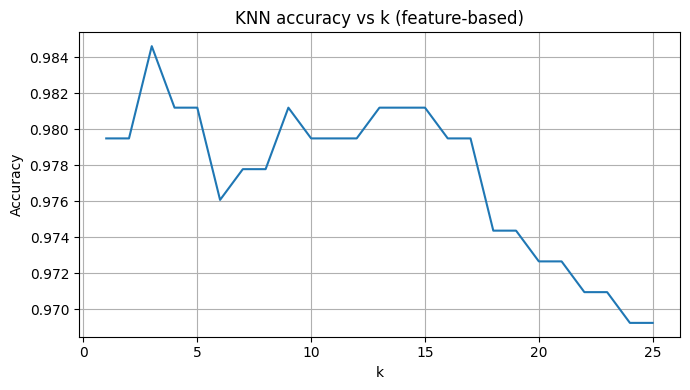

In [8]:
best_k = None
best_acc = -1
best_knn_model = None

accs = []
ks = list(range(1, 26))

for k in ks:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accs.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_knn_model = model

print("Best KNN k:", best_k, " test acc:", best_acc)

# Evaluate best
y_pred = best_knn_model.predict(X_test)
print("\nConfusion Matrix (KNN):\n", confusion_matrix(y_test, y_pred))
print("\nReport (KNN):\n", classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(ks, accs)
plt.grid(True)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN accuracy vs k (feature-based)")
plt.tight_layout()
plt.show()

### 5) SVM on features (small grid)

In [9]:
from sklearn.model_selection import ParameterGrid

param_grid = list(ParameterGrid({
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 1e-2],  # only used for rbf
}))

best_svm = None
best_svm_acc = -1
best_params = None

for params in param_grid:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(class_weight="balanced")),
    ])
    model.set_params(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    if acc > best_svm_acc:
        best_svm_acc = acc
        best_svm = model
        best_params = params

print("Best SVM params:", best_params, " test acc:", best_svm_acc)

y_pred = best_svm.predict(X_test)
print("\nConfusion Matrix (SVM):\n", confusion_matrix(y_test, y_pred))
print("\nReport (SVM):\n", classification_report(y_test, y_pred))

Best SVM params: {'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}  test acc: 0.9914529914529915

Confusion Matrix (SVM):
 [[527   5]
 [  0  53]]

Report (SVM):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       532
           1       0.91      1.00      0.95        53

    accuracy                           0.99       585
   macro avg       0.96      1.00      0.98       585
weighted avg       0.99      0.99      0.99       585



### 6) Feature ranking (Mutual Information + Permutation Importance)

In [10]:
# Mutual Information (nonlinear relevance)
mi = mutual_info_classif(X_train, y_train, random_state=0)
mi_order = np.argsort(mi)[::-1]

print("\nMutual Information ranking:")
for i in mi_order:
    print(f"{FEATURE_NAMES_12[i]:>16s}  MI={mi[i]:.4f}")

# Permutation importance on the best SVM (works well with StandardScaler in pipeline)
perm = permutation_importance(best_svm, X_test, y_test, n_repeats=20, random_state=0, scoring="accuracy")
perm_order = np.argsort(perm.importances_mean)[::-1]

print("\nPermutation importance ranking (accuracy drop):")
for i in perm_order:
    print(f"{FEATURE_NAMES_12[i]:>16s}  Δacc={perm.importances_mean[i]:.4f} ± {perm.importances_std[i]:.4f}")


Mutual Information ranking:
             rms  MI=0.2703
        peak_abs  MI=0.2222
          energy  MI=0.1516
        kurtosis  MI=0.0333
  rise_time_frac  MI=0.0292
             zcr  MI=0.0266
    crest_factor  MI=0.0208
 decay_time_frac  MI=0.0135
    spec_entropy  MI=0.0128
   spec_centroid  MI=0.0123
  spec_bandwidth  MI=0.0097
        skewness  MI=0.0096

Permutation importance ranking (accuracy drop):
             rms  Δacc=0.1062 ± 0.0070
        peak_abs  Δacc=0.0464 ± 0.0047
             zcr  Δacc=0.0240 ± 0.0037
   spec_centroid  Δacc=0.0106 ± 0.0020
    spec_entropy  Δacc=0.0078 ± 0.0033
        kurtosis  Δacc=0.0074 ± 0.0027
    crest_factor  Δacc=0.0069 ± 0.0034
 decay_time_frac  Δacc=0.0052 ± 0.0028
  rise_time_frac  Δacc=0.0043 ± 0.0020
  spec_bandwidth  Δacc=0.0031 ± 0.0017
          energy  Δacc=0.0029 ± 0.0012
        skewness  Δacc=0.0000 ± 0.0000


### 2D Phase plot

A 2D phase plot is a great next step because it lets you visually see whether events and non-events separate in feature space. Based on your importance results, the two most informative axes are:

RMS amplitude (strongest feature)

Zero Crossing Rate (ZCR) or Spectral Centroid (frequency content)

I suggest plotting two phase spaces:

1️⃣ RMS vs ZCR
2️⃣ RMS vs Spectral Centroid

This often reveals clear clusters.

Below is a cell you can add to your notebook.

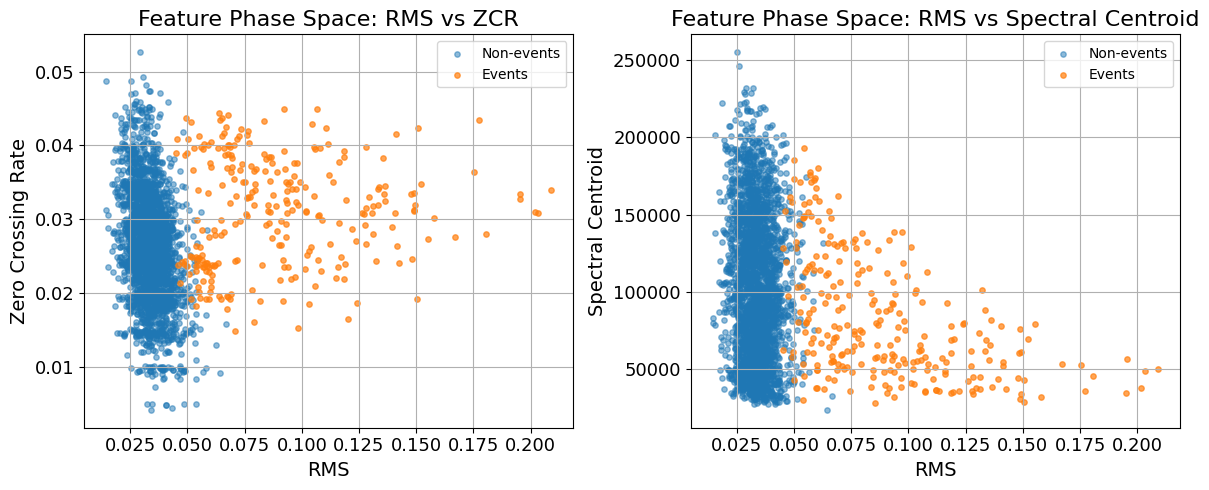

In [11]:
import matplotlib.pyplot as plt
import numpy as np

FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

# feature indices
idx_rms = FEATURE_NAMES_12.index("rms")
idx_zcr = FEATURE_NAMES_12.index("zcr")
idx_centroid = FEATURE_NAMES_12.index("spec_centroid")

# separate classes
events = y_feat == 1
non_events = y_feat == 0

fig, axes = plt.subplots(1,2, figsize=(12,5))

# ---- RMS vs ZCR ----
axes[0].scatter(
    X_feat[non_events, idx_rms],
    X_feat[non_events, idx_zcr],
    s=15,
    alpha=0.5,
    label="Non-events"
)

axes[0].scatter(
    X_feat[events, idx_rms],
    X_feat[events, idx_zcr],
    s=15,
    alpha=0.7,
    label="Events"
)

axes[0].set_xlabel("RMS", fontsize=FONT_LABEL)
axes[0].set_ylabel("Zero Crossing Rate", fontsize=FONT_LABEL)
axes[0].set_title("Feature Phase Space: RMS vs ZCR", fontsize=FONT_TITLE)
axes[0].tick_params(labelsize=FONT_TICKS)
axes[0].grid(True)
axes[0].legend()

# ---- RMS vs Spectral Centroid ----
axes[1].scatter(
    X_feat[non_events, idx_rms],
    X_feat[non_events, idx_centroid],
    s=15,
    alpha=0.5,
    label="Non-events"
)

axes[1].scatter(
    X_feat[events, idx_rms],
    X_feat[events, idx_centroid],
    s=15,
    alpha=0.7,
    label="Events"
)

axes[1].set_xlabel("RMS", fontsize=FONT_LABEL)
axes[1].set_ylabel("Spectral Centroid", fontsize=FONT_LABEL)
axes[1].set_title("Feature Phase Space: RMS vs Spectral Centroid", fontsize=FONT_TITLE)
axes[1].tick_params(labelsize=FONT_TICKS)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### 3D phase-space plot

of RMS vs ZCR vs Spectral Centroid, colored by class (event vs non-event). It uses the X_feat, y_feat, and FEATURE_NAMES_12 you already built.

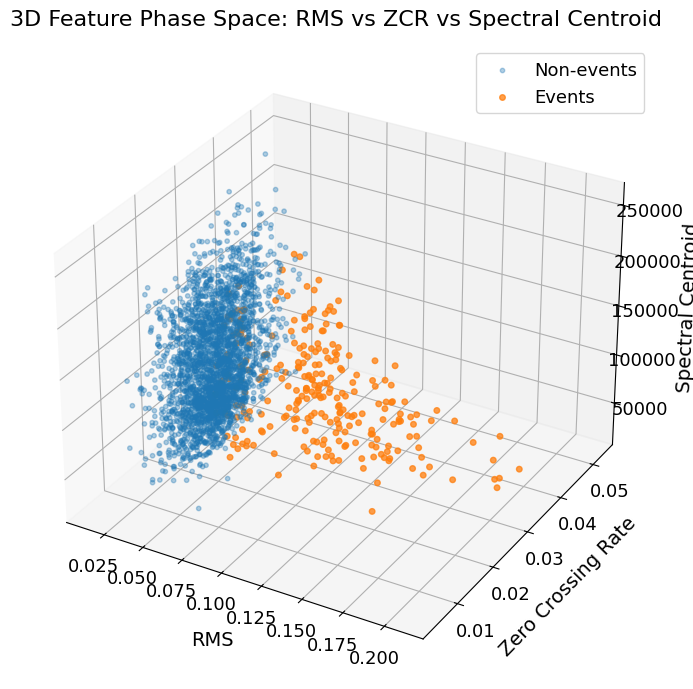

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

# feature indices
idx_rms = FEATURE_NAMES_12.index("rms")
idx_zcr = FEATURE_NAMES_12.index("zcr")
idx_centroid = FEATURE_NAMES_12.index("spec_centroid")

# masks
events = (y_feat == 1)
non_events = (y_feat == 0)

# data
x_rms = X_feat[:, idx_rms]
y_zcr = X_feat[:, idx_zcr]
z_cent = X_feat[:, idx_centroid]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_rms[non_events],
    y_zcr[non_events],
    z_cent[non_events],
    s=10,
    alpha=0.35,
    label="Non-events",
)

ax.scatter(
    x_rms[events],
    y_zcr[events],
    z_cent[events],
    s=16,
    alpha=0.75,
    label="Events",
)

ax.set_xlabel("RMS", fontsize=FONT_LABEL, labelpad=10)
ax.set_ylabel("Zero Crossing Rate", fontsize=FONT_LABEL, labelpad=10)
ax.set_zlabel("Spectral Centroid", fontsize=FONT_LABEL, labelpad=10)

ax.tick_params(axis="both", labelsize=FONT_TICKS)
ax.set_title("3D Feature Phase Space: RMS vs ZCR vs Spectral Centroid", fontsize=FONT_TITLE, pad=14)

ax.legend(fontsize=FONT_TICKS)
plt.tight_layout()
plt.show()

### Wavelet features

To explore “multiple AE mechanisms hidden inside ‘event’” you should treat it as an unsupervised (or weakly supervised) discovery problem on the event set only. The goal is to see whether events naturally split into stable clusters that correspond to different physics (microcracking vs frictional slip vs sensor ringing, etc.), and whether those clusters map to the mechanical state (strain/stress, stress derivative, time-to-failure).

What to look for (quick checklist)

- Do clusters separate in PCA/UMAP?
- Do wavelet fraction means differ by cluster? (e.g., Cluster 0 high w_frac_D1, Cluster 1 high w_frac_A3)
- Do representative waveforms look qualitatively different? (impulsive vs ringing vs longer/rougher)
- Do clusters correlate with mechanics? (histogram of dstress_dt_n per cluster, or plot cluster vs time)



Event-only feature matrix: (266, 14)
Features: ['log_duration', 'rise_time_frac', 'decay_time_frac', 'kurtosis', 'zcr', 'spec_centroid_n', 'spec_bandwidth_n', 'spec_entropy', 'w_frac_D1', 'w_frac_D2', 'w_frac_D3', 'w_frac_A3', 'w_entropy', 'w_high_frac']
PCA explained variance ratio: [0.33913414 0.18775186]
Best GMM k by BIC: 4


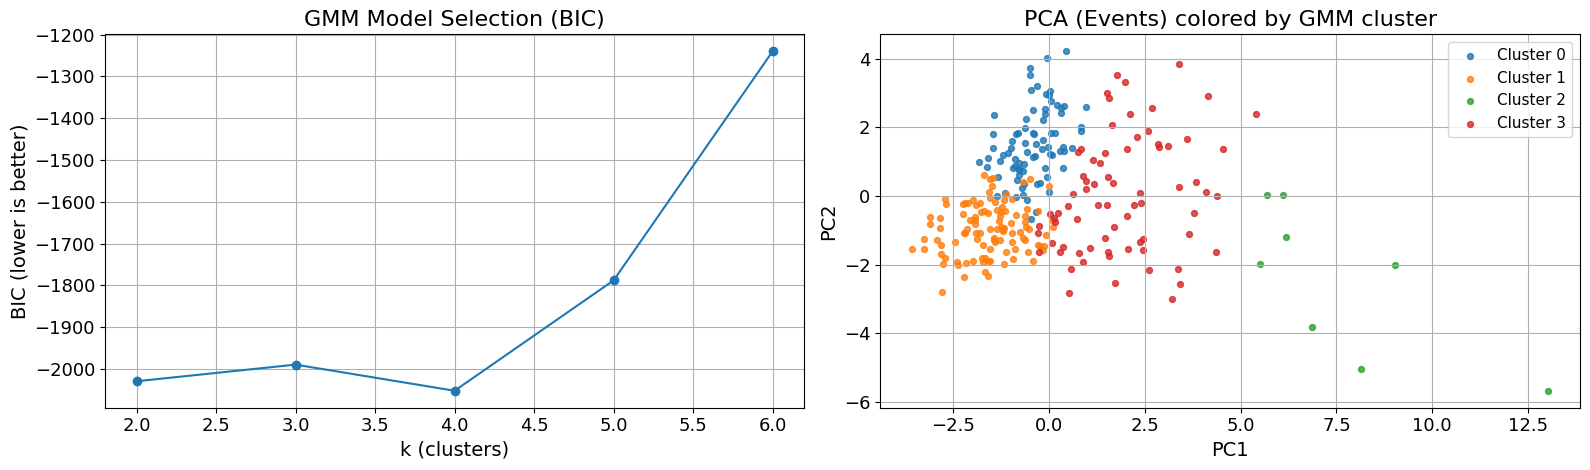

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


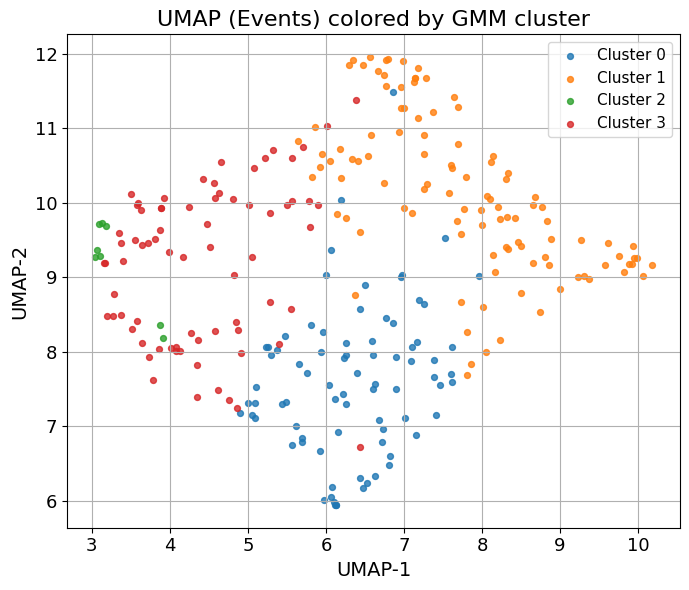

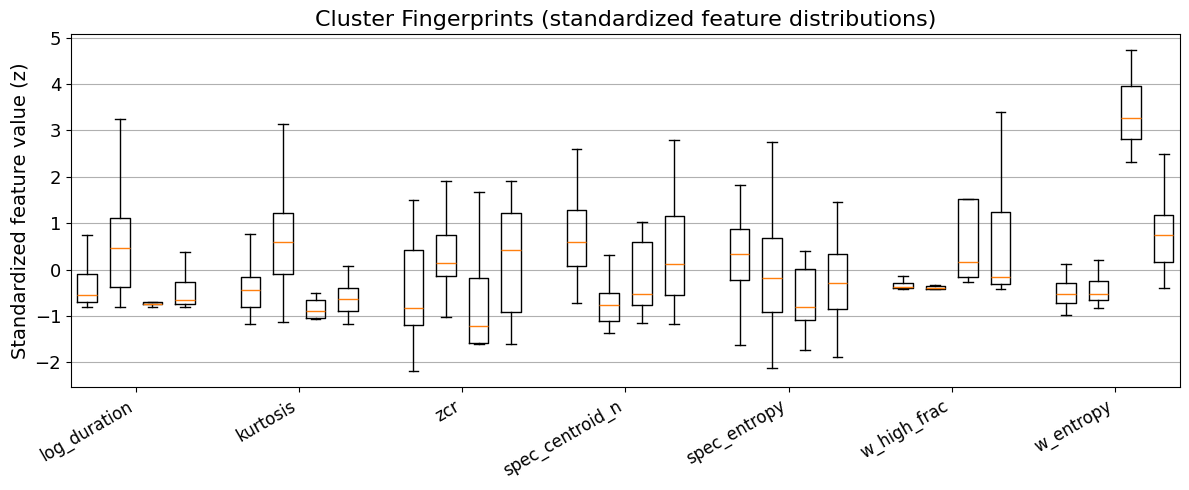

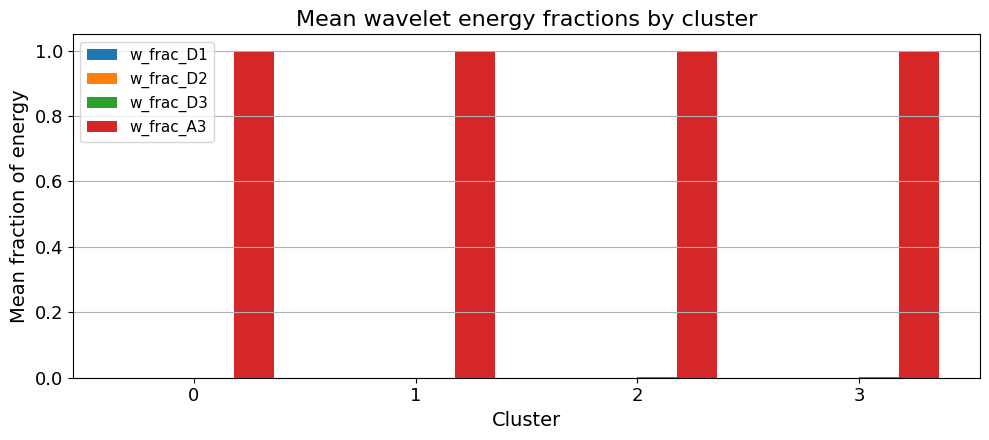

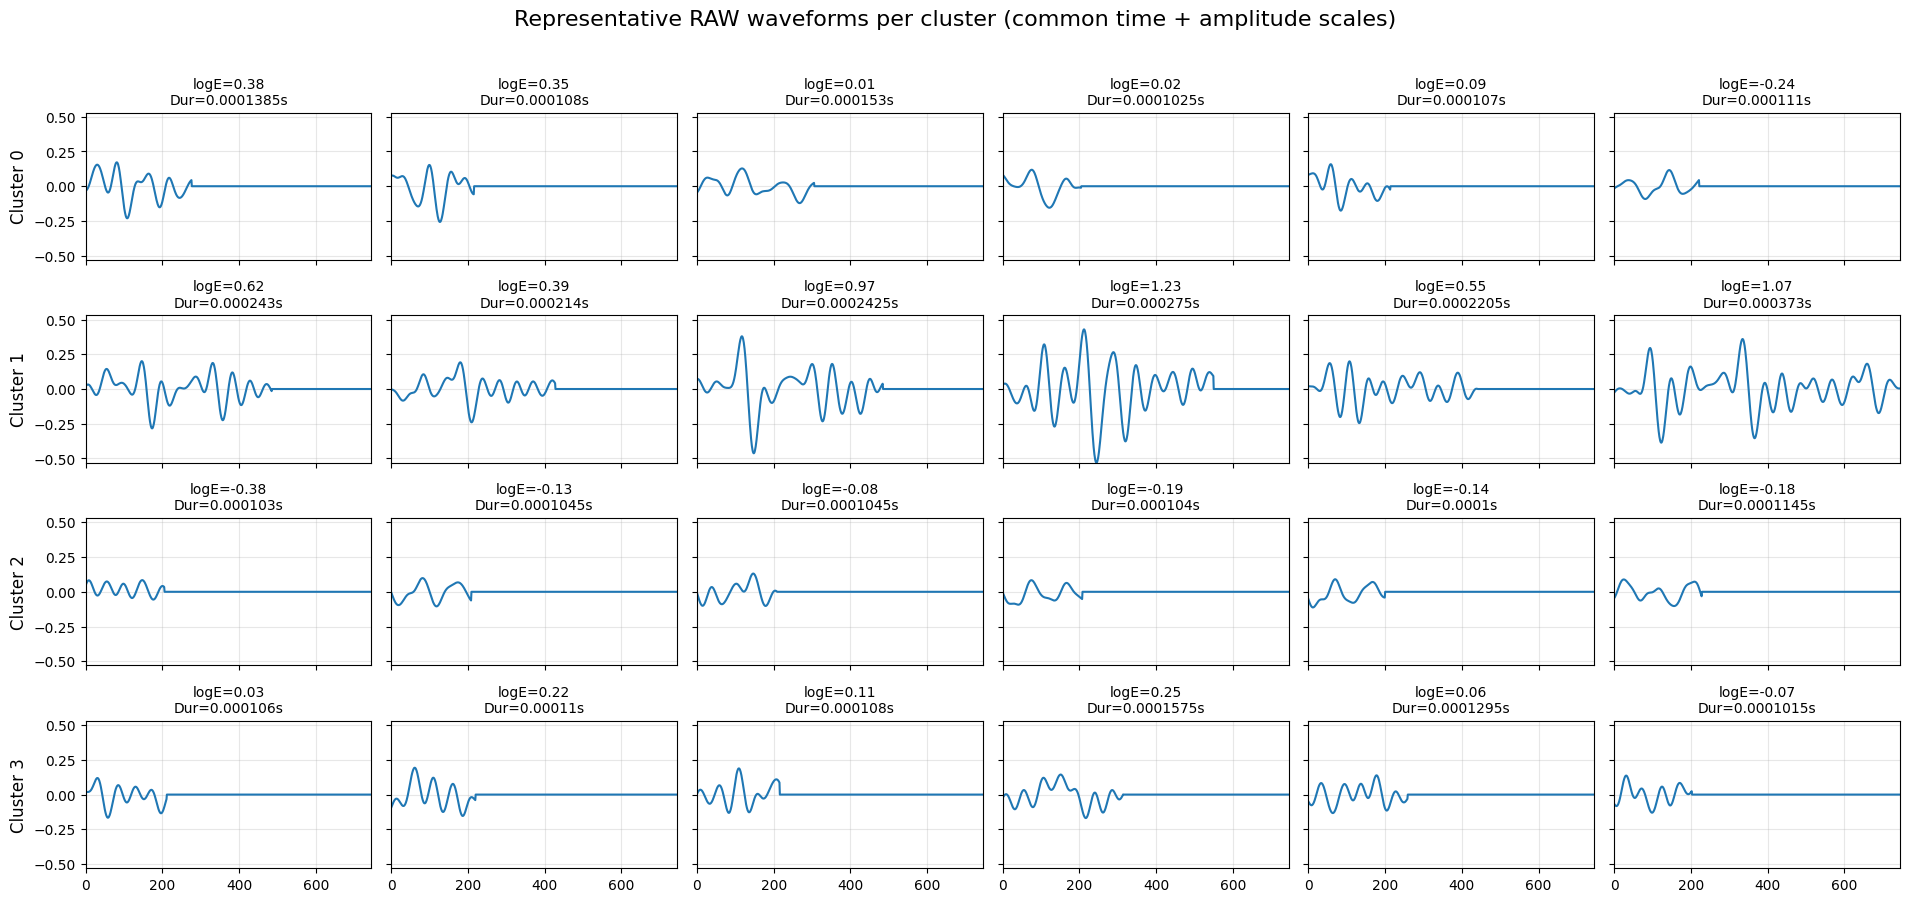

Common length (samples): 746
Common amplitude |max|: 0.5304767489433289


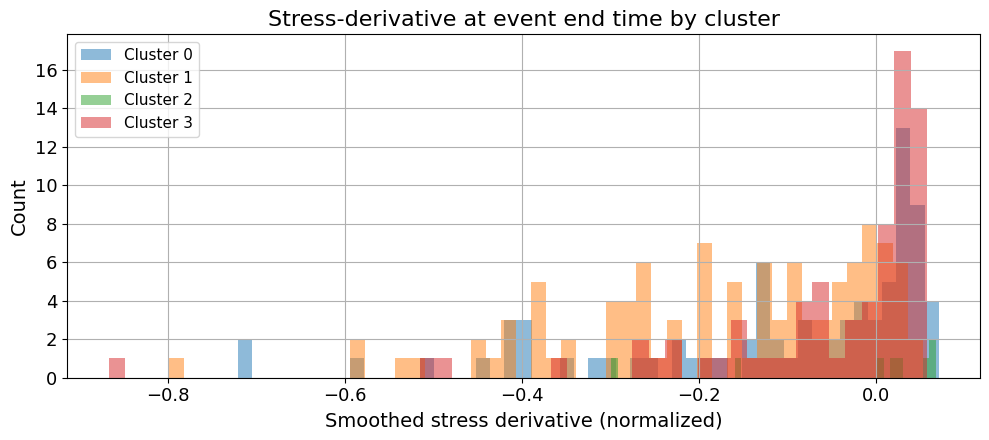

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import hilbert
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# ---- Optional wavelet lib ----
try:
    import pywt
    _HAS_PYWT = True
except Exception:
    _HAS_PYWT = False
    print("pywt not available. Install pywavelets to enable wavelet features (pip install PyWavelets).")

# ---- Optional UMAP ----
try:
    import umap
    _HAS_UMAP = True
except Exception:
    _HAS_UMAP = False
    print("UMAP not available. Install umap-learn for UMAP plots (pip install umap-learn).")

# ---------------------------
# Mechanism-focused features
# ---------------------------
# Features emphasize shape/time-frequency distribution rather than raw amplitude.
MECH_FEATURE_NAMES = [
    "log_duration",
    "rise_time_frac",
    "decay_time_frac",
    "kurtosis",
    "zcr",
    "spec_centroid_n",
    "spec_bandwidth_n",
    "spec_entropy",
]

# Wavelet fraction/entropy names (added if pywt is available)
WAVELET_FEATURE_NAMES = [
    "w_frac_D1", "w_frac_D2", "w_frac_D3", "w_frac_A3", "w_entropy", "w_high_frac"
]

def _rms(x, eps=1e-12):
    return float(np.sqrt(np.mean(x*x))) + eps

def _normalize_rms(x):
    return x / _rms(x)

def _zcr(x):
    # zero-crossing rate per sample
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def _spec_features_normalized_freq(x):
    """
    Spectral features using normalized frequency bins (cycles/sample),
    so we do not need an absolute fs.
    """
    N = len(x)
    X = np.fft.rfft(x)
    mag = np.abs(X)
    mag[0] = 0.0
    f = np.fft.rfftfreq(N, d=1.0)  # cycles/sample, in [0, 0.5]
    mag_sum = float(np.sum(mag)) + 1e-12
    p = mag / mag_sum

    centroid = float(np.sum(f * mag) / mag_sum)
    bandwidth = float(np.sqrt(np.sum(((f - centroid) ** 2) * mag) / mag_sum))
    entropy = float(-np.sum(p * np.log(p + 1e-12)))
    return centroid, bandwidth, entropy

def _envelope_rise_decay_fracs(x):
    env = np.abs(hilbert(x))
    N = len(env)
    pk = int(np.argmax(env))
    rise = float(pk / max(N - 1, 1))

    pk_env = float(env[pk])
    target = pk_env / np.e
    after = env[pk:]
    below = np.where(after <= target)[0]
    if below.size > 0:
        dec_idx = pk + int(below[0])
    else:
        dec_idx = N - 1
    decay = float((dec_idx - pk) / max(N - 1, 1))
    return rise, decay

def _wavelet_fractions_entropy(x, wavelet="db4", level=3):
    """
    DWT at level=3: coeffs = [A3, D3, D2, D1]
    Return fractions of energy in D1,D2,D3,A3 + entropy + high_frac (D1 fraction).
    """
    if not _HAS_PYWT:
        return None

    coeffs = pywt.wavedec(x, wavelet, level=level)
    # coeffs[0]=A3, coeffs[1]=D3, coeffs[2]=D2, coeffs[3]=D1
    A3, D3, D2, D1 = coeffs[0], coeffs[1], coeffs[2], coeffs[3]

    EA3 = float(np.sum(np.asarray(A3)**2))
    ED3 = float(np.sum(np.asarray(D3)**2))
    ED2 = float(np.sum(np.asarray(D2)**2))
    ED1 = float(np.sum(np.asarray(D1)**2))

    Etot = EA3 + ED3 + ED2 + ED1 + 1e-12
    frD1 = ED1 / Etot
    frD2 = ED2 / Etot
    frD3 = ED3 / Etot
    frA3 = EA3 / Etot

    p = np.array([frD1, frD2, frD3, frA3], dtype=float)
    went = float(-np.sum(p * np.log(p + 1e-12)))

    return frD1, frD2, frD3, frA3, went, frD1

def extract_mechanism_features(event_record, wavelet="db4", level=3):
    sig = event_record.get("signal", None)
    if sig is None:
        return None, None

    x = np.asarray(sig, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 32:
        return None, None

    # keep energy/duration as metadata (not for clustering dominance)
    energy = float(np.sum(x**2))
    duration_s = float(event_record.get("duration_s", x.size))  # fallback to samples if absent
    log_duration = float(np.log10(duration_s + 1e-12))

    # amplitude-normalize to focus on morphology / mechanism
    xn = _normalize_rms(x)

    rise, decay = _envelope_rise_decay_fracs(xn)
    k = float(kurtosis(xn, fisher=False, bias=False))
    z = _zcr(xn)
    cent, bw, sent = _spec_features_normalized_freq(xn)

    feats = [
        log_duration,
        rise,
        decay,
        k,
        z,
        cent,
        bw,
        sent,
    ]

    wfeats = _wavelet_fractions_entropy(xn, wavelet=wavelet, level=level)
    if wfeats is not None:
        feats.extend(list(wfeats))

    return np.array(feats, dtype=float), {"energy": energy, "duration_s": duration_s}

# ---------------------------
# Build event-only dataset
# ---------------------------
events_sorted = sorted(combined_events.values(), key=lambda e: e.get("global_start_time_s", 0.0))

X_list = []
meta = {"energy": [], "duration_s": [], "t_onset": [], "t_end": []}

for ev in events_sorted:
    feats, md = extract_mechanism_features(ev, wavelet="db4", level=3)
    if feats is None:
        continue

    X_list.append(feats)

    onset = float(ev.get("global_start_time_s", np.nan))
    dur = float(ev.get("duration_s", 0.0))
    t_end = onset + dur

    meta["energy"].append(md["energy"])
    meta["duration_s"].append(md["duration_s"])
    meta["t_onset"].append(onset)
    meta["t_end"].append(t_end)

X_event = np.vstack(X_list)
for k in meta:
    meta[k] = np.asarray(meta[k], dtype=float)

# Names
feature_names = MECH_FEATURE_NAMES.copy()
if _HAS_PYWT:
    feature_names += WAVELET_FEATURE_NAMES

print("Event-only feature matrix:", X_event.shape)
print("Features:", feature_names)

# ---------------------------
# Standardize & PCA (2D)
# ---------------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X_event)

pca = PCA(n_components=2, random_state=0)
Xp = pca.fit_transform(Xz)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# ---------------------------
# GMM clustering: choose k by BIC
# ---------------------------
Ks = list(range(2, 7))
bics = []
models = []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0, n_init=10)
    gmm.fit(Xz)
    bics.append(gmm.bic(Xz))
    models.append(gmm)

best_i = int(np.argmin(bics))
best_k = Ks[best_i]
best_gmm = models[best_i]
labels = best_gmm.predict(Xz)

print("Best GMM k by BIC:", best_k)

# ---------------------------
# Plots: PCA + BIC curve
# ---------------------------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# BIC
axes[0].plot(Ks, bics, marker="o")
axes[0].set_title("GMM Model Selection (BIC)", fontsize=FONT_TITLE)
axes[0].set_xlabel("k (clusters)", fontsize=FONT_LABEL)
axes[0].set_ylabel("BIC (lower is better)", fontsize=FONT_LABEL)
axes[0].tick_params(labelsize=FONT_TICKS)
axes[0].grid(True)

# PCA colored by cluster
for c in range(best_k):
    m = labels == c
    axes[1].scatter(Xp[m, 0], Xp[m, 1], s=18, alpha=0.8, label=f"Cluster {c}")
axes[1].set_title("PCA (Events) colored by GMM cluster", fontsize=FONT_TITLE)
axes[1].set_xlabel("PC1", fontsize=FONT_LABEL)
axes[1].set_ylabel("PC2", fontsize=FONT_LABEL)
axes[1].tick_params(labelsize=FONT_TICKS)
axes[1].grid(True)
axes[1].legend(fontsize=11)

'''
# PCA colored by log energy
cvals = np.log10(meta["energy"] + 1e-12)
sc = axes[2].scatter(Xp[:, 0], Xp[:, 1], c=cvals, s=18, alpha=0.9)
axes[2].set_title("PCA colored by log10(energy)", fontsize=FONT_TITLE)
axes[2].set_xlabel("PC1", fontsize=FONT_LABEL)
axes[2].set_ylabel("PC2", fontsize=FONT_LABEL)
axes[2].tick_params(labelsize=FONT_TICKS)
axes[2].grid(True)
cb = plt.colorbar(sc, ax=axes[2])
cb.set_label("log10(energy)", fontsize=FONT_LABEL)
'''
plt.tight_layout()
plt.show()

# ---------------------------
# Optional UMAP visualization
# ---------------------------
if _HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=0)
    Xu = reducer.fit_transform(Xz)

    plt.figure(figsize=(7, 6))
    for c in range(best_k):
        m = labels == c
        plt.scatter(Xu[m, 0], Xu[m, 1], s=18, alpha=0.8, label=f"Cluster {c}")
    plt.title("UMAP (Events) colored by GMM cluster", fontsize=FONT_TITLE)
    plt.xlabel("UMAP-1", fontsize=FONT_LABEL)
    plt.ylabel("UMAP-2", fontsize=FONT_LABEL)
    plt.xticks(fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------
# Cluster fingerprints: feature boxplots + wavelet fractions means
# ---------------------------
# Choose a few key features to summarize (mechanism-sensitive)
keys_to_plot = [
    "log_duration",
    "kurtosis",
    "zcr",
    "spec_centroid_n",
    "spec_entropy",
]
# Add wavelet items if available
if _HAS_PYWT:
    keys_to_plot += ["w_high_frac", "w_entropy"]

idx_map = {name: i for i, name in enumerate(feature_names)}
plot_idxs = [idx_map[k] for k in keys_to_plot if k in idx_map]

fig, ax = plt.subplots(figsize=(12, 5))
data = [Xz[labels == c][:, plot_idxs] for c in range(best_k)]

# Make boxplots per feature per cluster (simple layout by concatenating)
# We'll plot each feature separately as grouped boxplots.
positions = []
box_data = []
xticks = []
pos = 1

for fi, fname in zip(plot_idxs, [feature_names[i] for i in plot_idxs]):
    for c in range(best_k):
        box_data.append(Xz[labels == c, fi])
        positions.append(pos)
        pos += 1
    xticks.append((positions[-best_k] + positions[-1]) / 2)
    pos += 1  # gap between features

bp = ax.boxplot(box_data, positions=positions, widths=0.6, showfliers=False)
ax.set_title("Cluster Fingerprints (standardized feature distributions)", fontsize=FONT_TITLE)
ax.set_ylabel("Standardized feature value (z)", fontsize=FONT_LABEL)
ax.set_xticks(xticks)
ax.set_xticklabels([feature_names[i] for i in plot_idxs], rotation=30, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=FONT_TICKS)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Wavelet fraction bar chart (means) if available
if _HAS_PYWT:
    frac_names = ["w_frac_D1", "w_frac_D2", "w_frac_D3", "w_frac_A3"]
    frac_idxs = [idx_map[n] for n in frac_names]
    means = np.zeros((best_k, len(frac_idxs)))
    for c in range(best_k):
        means[c, :] = np.mean(X_event[labels == c][:, frac_idxs], axis=0)

    plt.figure(figsize=(10, 4.5))
    x = np.arange(best_k)
    width = 0.18
    for j, n in enumerate(frac_names):
        plt.bar(x + (j - 1.5) * width, means[:, j], width=width, label=n)
    plt.title("Mean wavelet energy fractions by cluster", fontsize=FONT_TITLE)
    plt.xlabel("Cluster", fontsize=FONT_LABEL)
    plt.ylabel("Mean fraction of energy", fontsize=FONT_LABEL)
    plt.xticks(x, [str(c) for c in range(best_k)], fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True, axis="y")
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------
# Representative waveforms per cluster (UN-normalized, common x/y scales)
# ---------------------------

def get_representative_indices(labels, Xz, cluster_id, n_show=6):
    """
    Choose representatives closest to the cluster mean in standardized feature space.
    """
    idx = np.where(labels == cluster_id)[0]
    if idx.size == 0:
        return []
    mu = np.mean(Xz[idx], axis=0)
    d = np.linalg.norm(Xz[idx] - mu, axis=1)
    order = np.argsort(d)
    return idx[order[:n_show]].tolist()

n_show = 6

# collect representative indices for each cluster
rep_by_cluster = {}
all_rep_indices = []
for c in range(best_k):
    rep = get_representative_indices(labels, Xz, c, n_show=n_show)
    rep_by_cluster[c] = rep
    all_rep_indices.extend(rep)

# determine common length (samples) across ALL reps (use max length)
lengths = []
amps = []
for idx in all_rep_indices:
    ev = events_sorted[idx]
    x = np.asarray(ev.get("signal", []), dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        continue
    lengths.append(x.size)
    amps.append(np.max(np.abs(x)))

if len(lengths) == 0:
    raise ValueError("No representative waveforms found to plot.")

L_common = int(np.max(lengths))  # common time duration in samples
ymax = float(np.max(amps))        # common amplitude scale (symmetric)

def pad_to_len(x, L):
    x = np.asarray(x, dtype=float)
    if x.size >= L:
        return x[:L]
    out = np.zeros(L, dtype=float)
    out[:x.size] = x
    return out

fig, axes = plt.subplots(best_k, n_show, figsize=(3.2*n_show, 2.2*best_k), sharex=True, sharey=True)
if best_k == 1:
    axes = np.array([axes])

for c in range(best_k):
    reps = rep_by_cluster[c]
    for j in range(n_show):
        ax = axes[c, j] if best_k > 1 else axes[j]
        ax.grid(True, alpha=0.3)

        if j >= len(reps):
            ax.axis("off")
            continue

        ev = events_sorted[reps[j]]
        x = np.asarray(ev.get("signal", []), dtype=float)
        x = x[np.isfinite(x)]
        x_plot = pad_to_len(x, L_common)

        ax.plot(x_plot)

        # consistent limits
        ax.set_xlim(0, L_common - 1)
        ax.set_ylim(-ymax, ymax)

        if j == 0:
            ax.set_ylabel(f"Cluster {c}", fontsize=12)

        # optional title with metadata
        ax.set_title(
            f"logE={np.log10(meta['energy'][reps[j]]+1e-12):.2f}\nDur={meta['duration_s'][reps[j]]:.4g}s",
            fontsize=10
        )

plt.suptitle("Representative RAW waveforms per cluster (common time + amplitude scales)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Common length (samples):", L_common)
print("Common amplitude |max|:", ymax)

# ---------------------------
# (Optional) Relate clusters to mechanics if available
# ---------------------------
# If you already computed dstress_dt_n on the same grid as strain_time (t array),
# we can map each event end time to the nearest stress-derivative sample and compare clusters.
if "dstress_dt_n" in globals() and "strain_time" in globals():
    t_mech = np.asarray(strain_time, dtype=float)
    d_mech = np.asarray(dstress_dt_n, dtype=float)

    # map event end times -> derivative samples
    idx_end = np.array([int(np.argmin(np.abs(t_mech - te))) for te in meta["t_end"]], dtype=int)
    d_at_end = d_mech[idx_end]

    plt.figure(figsize=(10, 4.5))
    for c in range(best_k):
        m = labels == c
        plt.hist(d_at_end[m], bins=50, alpha=0.5, label=f"Cluster {c}")
    plt.title("Stress-derivative at event end time by cluster", fontsize=FONT_TITLE)
    plt.xlabel("Smoothed stress derivative (normalized)", fontsize=FONT_LABEL)
    plt.ylabel("Count", fontsize=FONT_LABEL)
    plt.xticks(fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

In [13]:
import numpy as np
from scipy.stats import kurtosis

FS_AE = 2_000_000  # Hz

print("\nCluster Summary (sorted by number of events)\n")

# --- check required signals exist ---
if "strain_time" not in globals() or "dstress_dt_n" not in globals():
    raise ValueError("Need strain_time and dstress_dt_n in the notebook to compute median stress-derivative per cluster.")

t_mech = np.asarray(strain_time, dtype=float)
d_mech = np.asarray(dstress_dt_n, dtype=float)

# safety: sort mechanical timeline
order = np.argsort(t_mech)
t_mech = t_mech[order]
d_mech = d_mech[order]

# compute event end times aligned with events_sorted order
event_end_times = np.array(
    [float(ev.get("global_start_time_s", np.nan)) + float(ev.get("duration_s", 0.0)) for ev in events_sorted],
    dtype=float
)

# map each event end time -> nearest mech sample index
event_end_idx = np.array([int(np.argmin(np.abs(t_mech - te))) for te in event_end_times], dtype=int)
event_d_at_end = d_mech[event_end_idx]

# compute cluster sizes & sort
cluster_ids = np.unique(labels)
cluster_sizes = {c: int(np.sum(labels == c)) for c in cluster_ids}
sorted_clusters = sorted(cluster_ids, key=lambda c: cluster_sizes[c], reverse=True)

report_features = [
    "rms",
    "peak_abs",
    "energy",
    "kurtosis",
    "zcr",
    "spec_centroid_khz",
    "spec_entropy",
    "median_duration_us",
    "median_dstress_dt",
]
'''
# --- HEADER WITH UNITS AND SCALE TYPE ---
header = [
    "cluster",
    "count",
    "rms (linear)",
    "peak_abs (linear)",
    "energy (linear)",
    "kurtosis (unitless)",
    "zcr (cross/sample, linear)",
    "spec_centroid (kHz, linear)",
    "spec_entropy (unitless)",
    "median_duration (µs, linear)",
    "median_dstress_dt (linear)",
]
'''
header = [
    "cluster",
    "count",
    "rms",
    "peak_abs",
    "energy",
    "kurtosis",
    "zcr (cross/sample)",
    "spec_centroid (kHz)",
    "spec_entropy",
    "median_duration (µs)",
    "median_dstress_dt",
]
row_format = "{:<8}" + "{:<18}" * (len(header) - 1)

print(row_format.format(*header))
print("-" * (18 * len(header)))

for c in sorted_clusters:
    mask = labels == c
    idxs = np.where(mask)[0]

    rms_vals = []
    peak_vals = []
    energy_vals = []
    kurt_vals = []
    zcr_vals = []
    centroid_khz_vals = []
    entropy_vals = []
    duration_us_vals = []

    for i in idxs:
        ev = events_sorted[i]

        # duration in microseconds
        dur_s = ev.get("duration_s", None)
        if dur_s is None:
            sig = ev.get("signal", [])
            dur_s = (len(sig) / FS_AE) if sig is not None else np.nan

        duration_us_vals.append(float(dur_s) * 1e6)

        x = np.asarray(ev["signal"], dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 8:
            continue

        rms = np.sqrt(np.mean(x**2))
        rms_vals.append(rms)
        peak_vals.append(np.max(np.abs(x)))
        energy_vals.append(np.sum(x**2))

        xn = x / (rms + 1e-12)

        kurt_vals.append(kurtosis(xn, fisher=False))
        zcr_vals.append(np.mean(np.signbit(xn[1:]) != np.signbit(xn[:-1])))

        # --- spectral centroid ---
        X = np.fft.rfft(xn)
        mag = np.abs(X)
        mag[0] = 0.0

        f_hz = np.fft.rfftfreq(len(xn), d=1.0 / FS_AE)
        mag_sum = np.sum(mag) + 1e-12

        centroid_hz = np.sum(f_hz * mag) / mag_sum
        centroid_khz_vals.append(centroid_hz / 1000.0)

        p = mag / mag_sum
        entropy_vals.append(-np.sum(p * np.log(p + 1e-12)))

    # median stress derivative
    med_dstress = float(np.median(event_d_at_end[idxs])) if idxs.size else np.nan

    row = [
        c,
        int(idxs.size),
        np.median(rms_vals) if rms_vals else np.nan,
        np.median(peak_vals) if peak_vals else np.nan,
        np.median(energy_vals) if energy_vals else np.nan,
        np.median(kurt_vals) if kurt_vals else np.nan,
        np.median(zcr_vals) if zcr_vals else np.nan,
        np.median(centroid_khz_vals) if centroid_khz_vals else np.nan,
        np.median(entropy_vals) if entropy_vals else np.nan,
        np.median(duration_us_vals) if duration_us_vals else np.nan,
        med_dstress,
    ]

    formatted = []
    for v in row:
        if isinstance(v, (int, np.integer)):
            formatted.append(v)
        else:
            formatted.append(f"{v:.4g}")

    print(row_format.format(*formatted))


Cluster Summary (sorted by number of events)

cluster count             rms               peak_abs          energy            kurtosis          zcr (cross/sample)spec_centroid (kHz)spec_entropy      median_duration (µs)median_dstress_dt 
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1       105               0.1119            0.3401            4.995             4.166             0.03198           51.45             2.75              207               -0.1339           
0       80                0.07501           0.1707            1.585             2.654             0.02489           106.1             3.046             116               -0.02766          
3       73                0.06392           0.1383            0.9153            2.395             0.03398           86.81             2.698             110               0.008158      

### Clean clustering code with frequency scale (non-normalized)

Event-only feature matrix: (266, 14)
Features: ['log_duration', 'rise_time_frac', 'decay_time_frac', 'kurtosis', 'zcr_hz', 'spec_centroid_khz', 'spec_bandwidth_khz', 'spec_entropy', 'w_frac_D1', 'w_frac_D2', 'w_frac_D3', 'w_frac_A3', 'w_entropy', 'w_high_frac']
PCA explained variance ratio: [0.33913414 0.18775186]
Best GMM k by BIC: 4


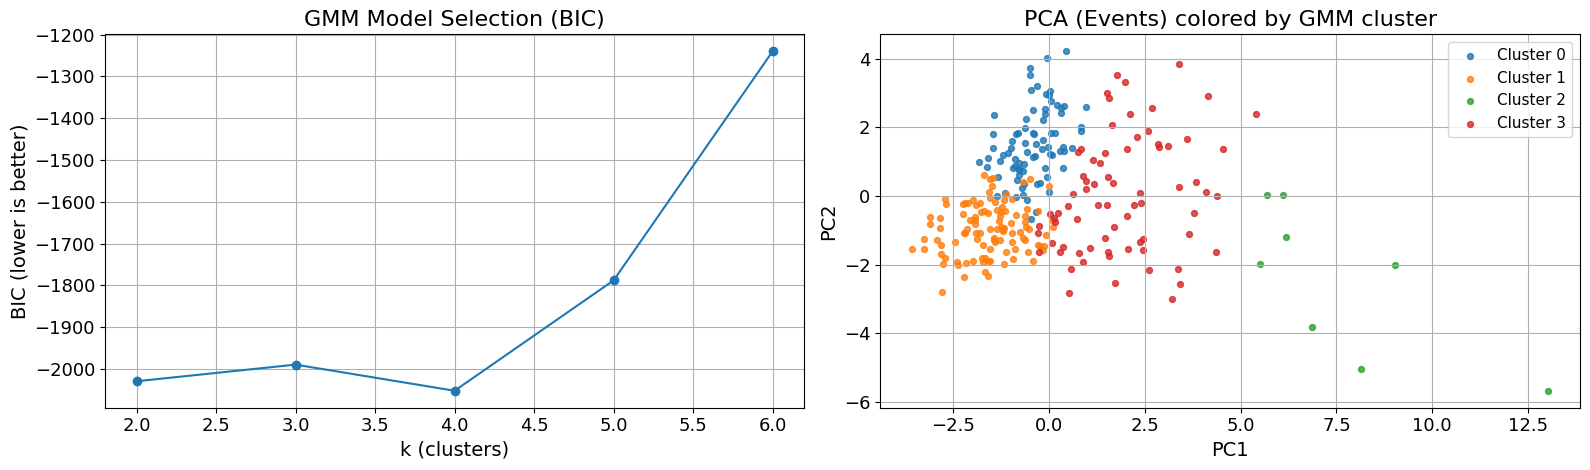

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


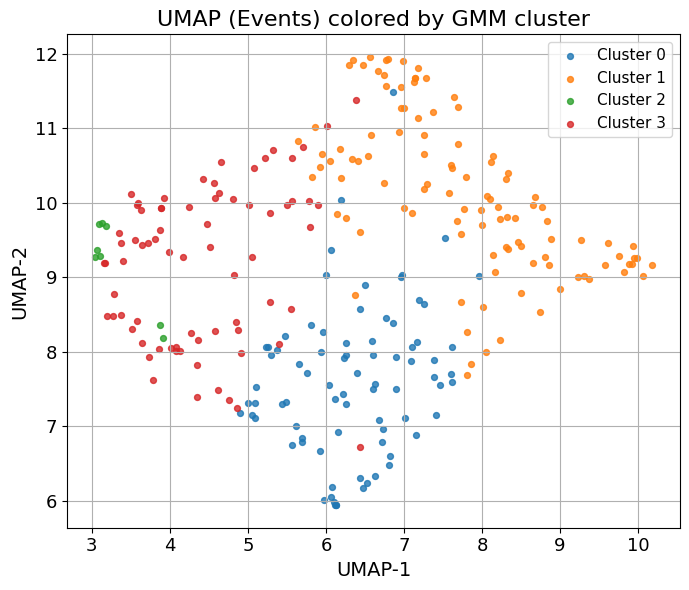

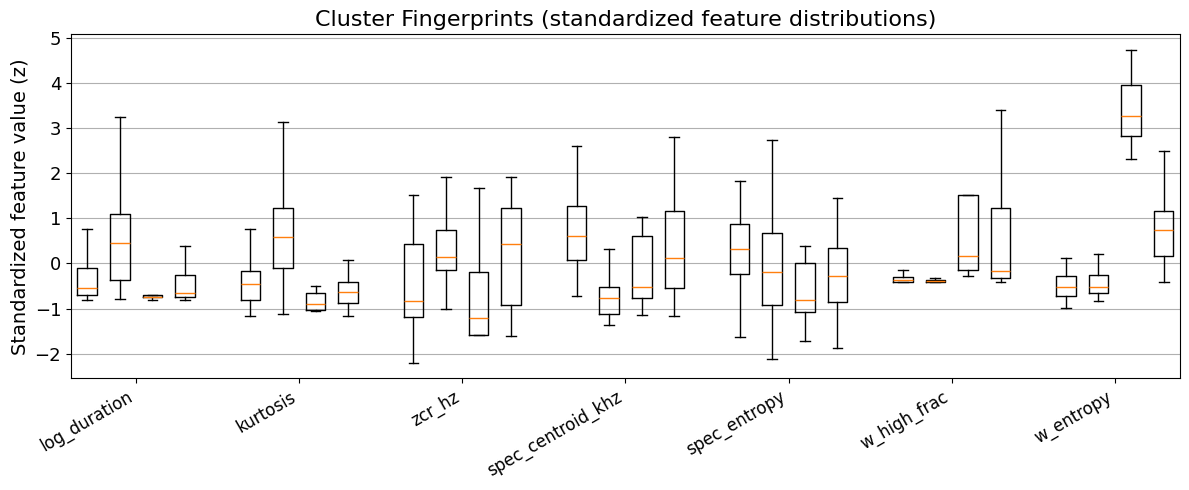

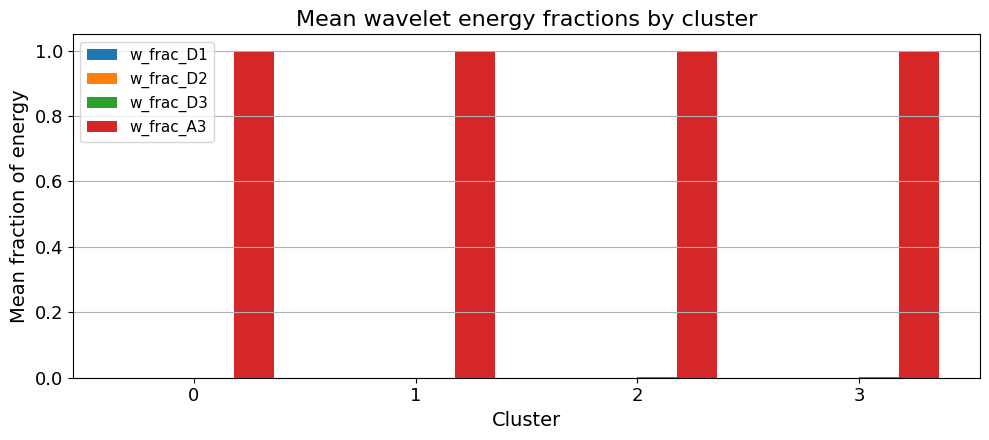

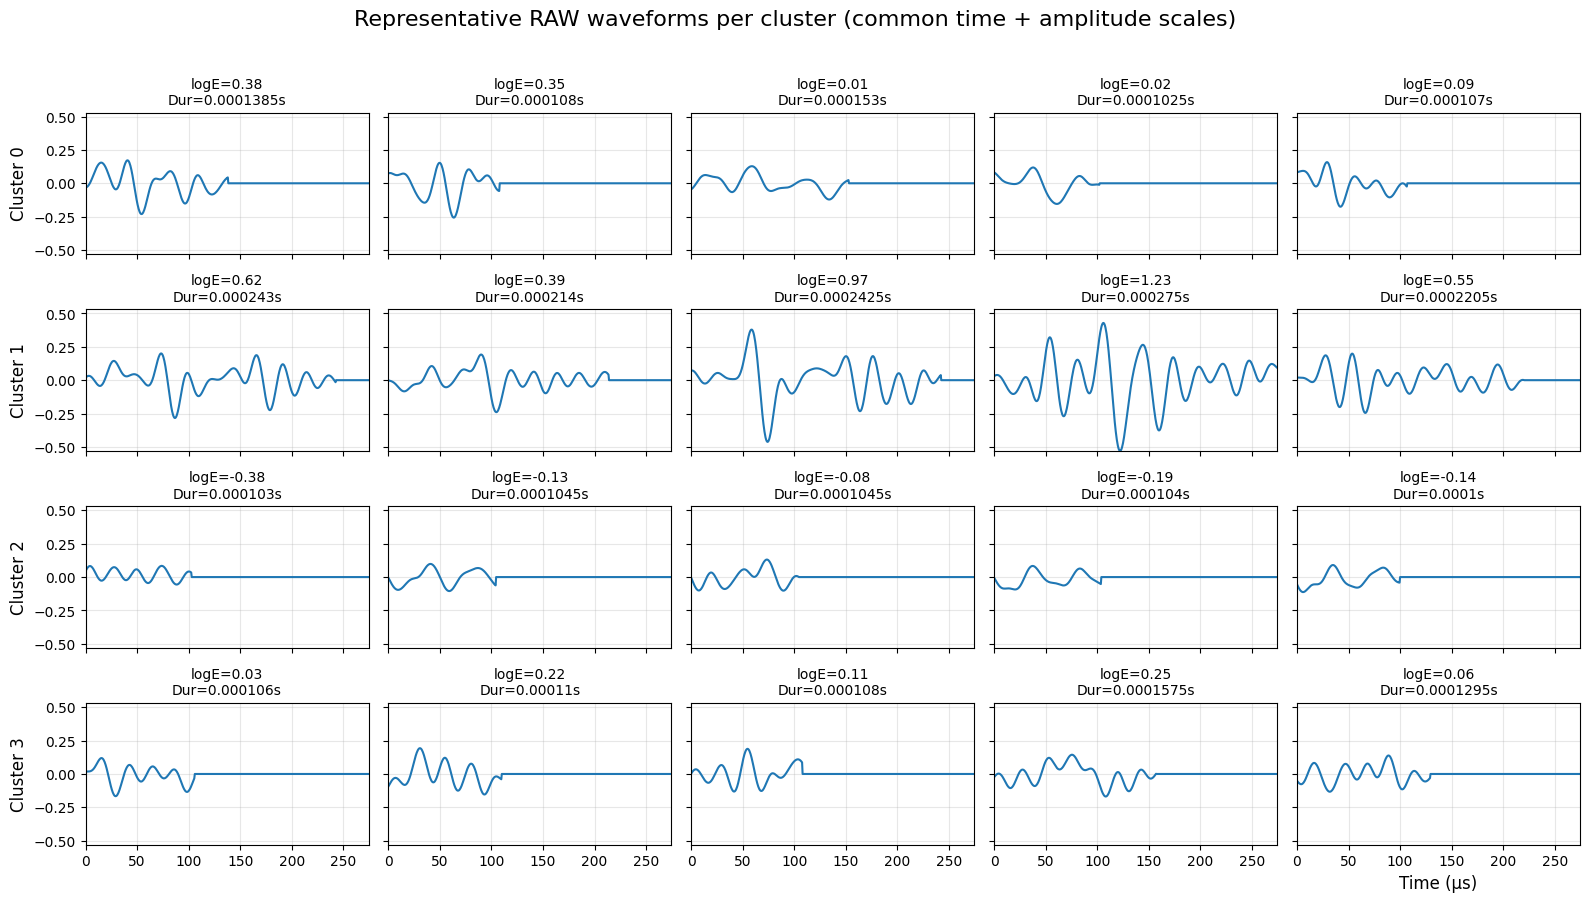

Common length (samples): 550
Common length (microseconds): 275.0
Common amplitude |max|: 0.5304767489433289


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import hilbert
from scipy.stats import kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# ---- Optional wavelet lib ----
try:
    import pywt
    _HAS_PYWT = True
except Exception:
    _HAS_PYWT = False
    print("pywt not available. Install pywavelets to enable wavelet features (pip install PyWavelets).")

# ---- Optional UMAP ----
try:
    import umap
    _HAS_UMAP = True
except Exception:
    _HAS_UMAP = False
    print("UMAP not available. Install umap-learn for UMAP plots (pip install umap-learn).")

# ---------------------------
# Global settings
# ---------------------------
FS_HZ = 2_000_000.0  # sampling rate in Hz

# ---------------------------
# Mechanism-focused features
# ---------------------------
# Features emphasize shape/time-frequency distribution rather than raw amplitude.
MECH_FEATURE_NAMES = [
    "log_duration",
    "rise_time_frac",
    "decay_time_frac",
    "kurtosis",
    "zcr_hz",             # <-- now in Hz (zero-crossing frequency proxy)
    "spec_centroid_khz",  # <-- now in kHz
    "spec_bandwidth_khz", # <-- now in kHz
    "spec_entropy",
]

# Wavelet fraction/entropy names (added if pywt is available)
WAVELET_FEATURE_NAMES = [
    "w_frac_D1", "w_frac_D2", "w_frac_D3", "w_frac_A3", "w_entropy", "w_high_frac"
]

# ---------------------------
# Helper functions
# ---------------------------
def _rms(x, eps=1e-12):
    return float(np.sqrt(np.mean(x * x))) + eps

def _normalize_rms(x):
    return x / _rms(x)

def _zcr_per_sample(x):
    # zero-crossing rate per sample (crossings/sample)
    return float(np.mean(np.signbit(x[1:]) != np.signbit(x[:-1])))

def _zcr_to_hz(zcr_per_sample, fs_hz):
    """
    Convert crossings/sample -> crossings/second.
    Note: for a clean sinusoid, crossings/sec = 2*f.
    So a common 'frequency proxy' is f_zc ≈ (zcr_hz)/2.
    Here we keep zcr_hz as crossings/sec (units are real Hz-like rate).
    """
    return float(zcr_per_sample * fs_hz)

def _spec_features_abs_freq(x, fs_hz):
    """
    Spectral features using absolute frequency bins in Hz.
    Returns centroid_hz, bandwidth_hz, entropy (unitless).
    """
    N = len(x)
    X = np.fft.rfft(x)
    mag = np.abs(X)
    if mag.size == 0:
        return np.nan, np.nan, np.nan

    mag[0] = 0.0
    f_hz = np.fft.rfftfreq(N, d=1.0 / fs_hz)  # Hz, in [0, fs/2]

    mag_sum = float(np.sum(mag)) + 1e-12
    p = mag / mag_sum

    centroid_hz = float(np.sum(f_hz * mag) / mag_sum)
    bandwidth_hz = float(np.sqrt(np.sum(((f_hz - centroid_hz) ** 2) * mag) / mag_sum))
    entropy = float(-np.sum(p * np.log(p + 1e-12)))
    return centroid_hz, bandwidth_hz, entropy

def _envelope_rise_decay_fracs(x):
    env = np.abs(hilbert(x))
    N = len(env)
    pk = int(np.argmax(env))
    rise = float(pk / max(N - 1, 1))

    pk_env = float(env[pk])
    target = pk_env / np.e
    after = env[pk:]
    below = np.where(after <= target)[0]
    if below.size > 0:
        dec_idx = pk + int(below[0])
    else:
        dec_idx = N - 1
    decay = float((dec_idx - pk) / max(N - 1, 1))
    return rise, decay

def _wavelet_fractions_entropy(x, wavelet="db4", level=3):
    """
    DWT at level=3: coeffs = [A3, D3, D2, D1]
    Return fractions of energy in D1,D2,D3,A3 + entropy + high_frac (D1 fraction).
    """
    if not _HAS_PYWT:
        return None

    coeffs = pywt.wavedec(x, wavelet, level=level)
    # coeffs[0]=A3, coeffs[1]=D3, coeffs[2]=D2, coeffs[3]=D1
    A3, D3, D2, D1 = coeffs[0], coeffs[1], coeffs[2], coeffs[3]

    EA3 = float(np.sum(np.asarray(A3) ** 2))
    ED3 = float(np.sum(np.asarray(D3) ** 2))
    ED2 = float(np.sum(np.asarray(D2) ** 2))
    ED1 = float(np.sum(np.asarray(D1) ** 2))

    Etot = EA3 + ED3 + ED2 + ED1 + 1e-12
    frD1 = ED1 / Etot
    frD2 = ED2 / Etot
    frD3 = ED3 / Etot
    frA3 = EA3 / Etot

    p = np.array([frD1, frD2, frD3, frA3], dtype=float)
    went = float(-np.sum(p * np.log(p + 1e-12)))

    return frD1, frD2, frD3, frA3, went, frD1

def extract_mechanism_features(event_record, fs_hz, wavelet="db4", level=3):
    sig = event_record.get("signal", None)
    if sig is None:
        return None, None

    x = np.asarray(sig, dtype=float)
    x = x[np.isfinite(x)]
    if x.size < 32:
        return None, None

    # metadata energy/duration
    energy = float(np.sum(x ** 2))
    duration_s = float(event_record.get("duration_s", x.size / fs_hz))  # fallback: samples -> seconds
    log_duration = float(np.log10(duration_s + 1e-12))

    # amplitude-normalize to focus on morphology / mechanism
    xn = _normalize_rms(x)

    rise, decay = _envelope_rise_decay_fracs(xn)
    k = float(kurtosis(xn, fisher=False, bias=False))

    z_ps = _zcr_per_sample(xn)
    z_hz = _zcr_to_hz(z_ps, fs_hz)

    cent_hz, bw_hz, sent = _spec_features_abs_freq(xn, fs_hz)

    feats = [
        log_duration,
        rise,
        decay,
        k,
        z_hz,
        cent_hz / 1e3,  # kHz
        bw_hz / 1e3,    # kHz
        sent,
    ]

    wfeats = _wavelet_fractions_entropy(xn, wavelet=wavelet, level=level)
    if wfeats is not None:
        feats.extend(list(wfeats))

    return np.array(feats, dtype=float), {"energy": energy, "duration_s": duration_s}

# ---------------------------
# Build event-only dataset
# ---------------------------
# Expecting combined_events: dict-like of event records
events_sorted = sorted(combined_events.values(), key=lambda e: e.get("global_start_time_s", 0.0))

X_list = []
meta = {"energy": [], "duration_s": [], "t_onset": [], "t_end": []}

for ev in events_sorted:
    feats, md = extract_mechanism_features(ev, fs_hz=FS_HZ, wavelet="db4", level=3)
    if feats is None:
        continue

    X_list.append(feats)

    onset = float(ev.get("global_start_time_s", np.nan))
    dur = float(ev.get("duration_s", md["duration_s"]))
    t_end = onset + dur

    meta["energy"].append(md["energy"])
    meta["duration_s"].append(md["duration_s"])
    meta["t_onset"].append(onset)
    meta["t_end"].append(t_end)

X_event = np.vstack(X_list)
for k in meta:
    meta[k] = np.asarray(meta[k], dtype=float)

# Names
feature_names = MECH_FEATURE_NAMES.copy()
if _HAS_PYWT:
    feature_names += WAVELET_FEATURE_NAMES

print("Event-only feature matrix:", X_event.shape)
print("Features:", feature_names)

# ---------------------------
# Standardize & PCA (2D)
# ---------------------------
scaler = StandardScaler()
Xz = scaler.fit_transform(X_event)

pca = PCA(n_components=2, random_state=0)
Xp = pca.fit_transform(Xz)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

# ---------------------------
# GMM clustering: choose k by BIC
# ---------------------------
Ks = list(range(2, 7))
bics = []
models = []

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0, n_init=10)
    gmm.fit(Xz)
    bics.append(gmm.bic(Xz))
    models.append(gmm)

best_i = int(np.argmin(bics))
best_k = Ks[best_i]
best_gmm = models[best_i]
labels = best_gmm.predict(Xz)

print("Best GMM k by BIC:", best_k)

# ---------------------------
# Plots: PCA + BIC curve
# ---------------------------
FONT_TITLE = 16
FONT_LABEL = 14
FONT_TICKS = 13

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))

# BIC
axes[0].plot(Ks, bics, marker="o")
axes[0].set_title("GMM Model Selection (BIC)", fontsize=FONT_TITLE)
axes[0].set_xlabel("k (clusters)", fontsize=FONT_LABEL)
axes[0].set_ylabel("BIC (lower is better)", fontsize=FONT_LABEL)
axes[0].tick_params(labelsize=FONT_TICKS)
axes[0].grid(True)

# PCA colored by cluster
for c in range(best_k):
    m = labels == c
    axes[1].scatter(Xp[m, 0], Xp[m, 1], s=18, alpha=0.8, label=f"Cluster {c}")
axes[1].set_title("PCA (Events) colored by GMM cluster", fontsize=FONT_TITLE)
axes[1].set_xlabel("PC1", fontsize=FONT_LABEL)
axes[1].set_ylabel("PC2", fontsize=FONT_LABEL)
axes[1].tick_params(labelsize=FONT_TICKS)
axes[1].grid(True)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# ---------------------------
# Optional UMAP visualization
# ---------------------------
if _HAS_UMAP:
    reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=0)
    Xu = reducer.fit_transform(Xz)

    plt.figure(figsize=(7, 6))
    for c in range(best_k):
        m = labels == c
        plt.scatter(Xu[m, 0], Xu[m, 1], s=18, alpha=0.8, label=f"Cluster {c}")
    plt.title("UMAP (Events) colored by GMM cluster", fontsize=FONT_TITLE)
    plt.xlabel("UMAP-1", fontsize=FONT_LABEL)
    plt.ylabel("UMAP-2", fontsize=FONT_LABEL)
    plt.xticks(fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------
# Cluster fingerprints: feature boxplots + wavelet fractions means
# ---------------------------
# Choose a few key features to summarize (mechanism-sensitive)
keys_to_plot = [
    "log_duration",
    "kurtosis",
    "zcr_hz",
    "spec_centroid_khz",
    "spec_entropy",
]
# Add wavelet items if available
if _HAS_PYWT:
    keys_to_plot += ["w_high_frac", "w_entropy"]

idx_map = {name: i for i, name in enumerate(feature_names)}
plot_idxs = [idx_map[k] for k in keys_to_plot if k in idx_map]

fig, ax = plt.subplots(figsize=(12, 5))
positions = []
box_data = []
xticks = []
pos = 1

for fi, fname in zip(plot_idxs, [feature_names[i] for i in plot_idxs]):
    for c in range(best_k):
        box_data.append(Xz[labels == c, fi])
        positions.append(pos)
        pos += 1
    xticks.append((positions[-best_k] + positions[-1]) / 2)
    pos += 1  # gap between features

ax.boxplot(box_data, positions=positions, widths=0.6, showfliers=False)
ax.set_title("Cluster Fingerprints (standardized feature distributions)", fontsize=FONT_TITLE)
ax.set_ylabel("Standardized feature value (z)", fontsize=FONT_LABEL)
ax.set_xticks(xticks)
ax.set_xticklabels([feature_names[i] for i in plot_idxs], rotation=30, ha="right", fontsize=12)
ax.tick_params(axis="y", labelsize=FONT_TICKS)
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

# Wavelet fraction bar chart (means) if available
if _HAS_PYWT:
    frac_names = ["w_frac_D1", "w_frac_D2", "w_frac_D3", "w_frac_A3"]
    frac_idxs = [idx_map[n] for n in frac_names]
    means = np.zeros((best_k, len(frac_idxs)))
    for c in range(best_k):
        means[c, :] = np.mean(X_event[labels == c][:, frac_idxs], axis=0)

    plt.figure(figsize=(10, 4.5))
    x = np.arange(best_k)
    width = 0.18
    for j, n in enumerate(frac_names):
        plt.bar(x + (j - 1.5) * width, means[:, j], width=width, label=n)
    plt.title("Mean wavelet energy fractions by cluster", fontsize=FONT_TITLE)
    plt.xlabel("Cluster", fontsize=FONT_LABEL)
    plt.ylabel("Mean fraction of energy", fontsize=FONT_LABEL)
    plt.xticks(x, [str(c) for c in range(best_k)], fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True, axis="y")
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------------------------
# Representative waveforms per cluster (UN-normalized, common x/y scales)
# ---------------------------
def get_representative_indices(labels, Xz, cluster_id, n_show=6):
    """
    Choose representatives closest to the cluster mean in standardized feature space.
    """
    idx = np.where(labels == cluster_id)[0]
    if idx.size == 0:
        return []
    mu = np.mean(Xz[idx], axis=0)
    d = np.linalg.norm(Xz[idx] - mu, axis=1)
    order = np.argsort(d)
    return idx[order[:n_show]].tolist()

n_show = 5

# collect representative indices for each cluster
rep_by_cluster = {}
all_rep_indices = []
for c in range(best_k):
    rep = get_representative_indices(labels, Xz, c, n_show=n_show)
    rep_by_cluster[c] = rep
    all_rep_indices.extend(rep)

# determine common length (samples) across ALL reps (use max length)
lengths = []
amps = []
for idx in all_rep_indices:
    ev = events_sorted[idx]
    x = np.asarray(ev.get("signal", []), dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        continue
    lengths.append(x.size)
    amps.append(np.max(np.abs(x)))

if len(lengths) == 0:
    raise ValueError("No representative waveforms found to plot.")

L_common = int(np.max(lengths))  # common time duration in samples
ymax = float(np.max(amps))       # common amplitude scale (symmetric)

def pad_to_len(x, L):
    x = np.asarray(x, dtype=float)
    if x.size >= L:
        return x[:L]
    out = np.zeros(L, dtype=float)
    out[:x.size] = x
    return out

# Build a time axis in microseconds (handy at 2 MHz)
t_us = (np.arange(L_common) / FS_HZ) * 1e6

fig, axes = plt.subplots(best_k, n_show, figsize=(3.2 * n_show, 2.2 * best_k), sharex=True, sharey=True)
if best_k == 1:
    axes = np.array([axes])

for c in range(best_k):
    reps = rep_by_cluster[c]
    for j in range(n_show):
        ax = axes[c, j] if best_k > 1 else axes[j]
        ax.grid(True, alpha=0.3)

        if j >= len(reps):
            ax.axis("off")
            continue

        ev = events_sorted[reps[j]]
        x = np.asarray(ev.get("signal", []), dtype=float)
        x = x[np.isfinite(x)]
        x_plot = pad_to_len(x, L_common)

        ax.plot(t_us, x_plot)

        # consistent limits
        ax.set_xlim(t_us[0], t_us[-1])
        ax.set_ylim(-ymax, ymax)

        if j == 0:
            ax.set_ylabel(f"Cluster {c}", fontsize=12)

        ax.set_title(
            f"logE={np.log10(meta['energy'][reps[j]] + 1e-12):.2f}\nDur={meta['duration_s'][reps[j]]:.4g}s",
            fontsize=10
        )

plt.suptitle("Representative RAW waveforms per cluster (common time + amplitude scales)", fontsize=16, y=1.02)
for ax in np.ravel(axes):
    if ax.has_data():
        ax.tick_params(labelsize=10)
plt.xlabel("Time (µs)", fontsize=12)
plt.tight_layout()
plt.show()

print("Common length (samples):", L_common)
print("Common length (microseconds):", float(L_common / FS_HZ * 1e6))
print("Common amplitude |max|:", ymax)

# ---------------------------
# (Optional) Relate clusters to mechanics if available
# ---------------------------
# If you already computed dstress_dt_n on the same grid as strain_time (t array),
# we can map each event end time to the nearest stress-derivative sample and compare clusters.
if "dstress_dt_n" in globals() and "strain_time" in globals():
    t_mech = np.asarray(strain_time, dtype=float)
    d_mech = np.asarray(dstress_dt_n, dtype=float)

    # map event end times -> derivative samples
    idx_end = np.array([int(np.argmin(np.abs(t_mech - te))) for te in meta["t_end"]], dtype=int)
    d_at_end = d_mech[idx_end]

    plt.figure(figsize=(10, 4.5))
    for c in range(best_k):
        m = labels == c
        plt.hist(d_at_end[m], bins=50, alpha=0.5, label=f"Cluster {c}")
    plt.title("Stress-derivative at event end time by cluster", fontsize=FONT_TITLE)
    plt.xlabel("Smoothed stress derivative (normalized)", fontsize=FONT_LABEL)
    plt.ylabel("Count", fontsize=FONT_LABEL)
    plt.xticks(fontsize=FONT_TICKS)
    plt.yticks(fontsize=FONT_TICKS)
    plt.grid(True)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()